# Temas 2 y 3 - El Diodo y sus Aplicaciones

**Fundamentos de Electrónica - 2º GIERM**

---

## Objetivos de aprendizaje

- Comprender la física de la unión PN y la ecuación de Shockley
- Conocer los tres modelos linealizados del diodo y cuándo usar cada uno
- Aplicar la metodología sistemática de análisis de circuitos con diodos
- Analizar rectificadores de media onda y onda completa
- Calcular el efecto del filtrado con condensador en rectificadores
- Diseñar reguladores de tensión con diodo Zener

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import schemdraw
import schemdraw.elements as elm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales
COLOR_RECTA = '#cb181d'       # rojo - rectas de carga, límites
COLOR_PUNTO = '#238b45'       # verde - puntos de operación
COLOR_N = '#a6cee3'           # azul claro - semiconductor tipo N
COLOR_P = '#b2df8a'           # verde claro - semiconductor tipo P

print('Configuración lista.')

Configuración lista.


---

# PARTE 1: El Diodo (Tema 2)

---

## 1. Introducción: Semiconductores

### 1.1 Materiales semiconductores

Los materiales semiconductores más utilizados en electrónica son el **silicio (Si)** y el **germanio (Ge)**, ambos de la columna IV de la tabla periódica. Su estructura cristalina es de tipo diamante, con **4 enlaces covalentes** por átomo.

A temperatura ambiente, algunos enlaces se rompen generando **pares electrón-hueco**. La recombinación es el proceso inverso.

### 1.2 Semiconductor intrínseco

En un semiconductor puro (intrínseco), la concentración de electrones $n$ y huecos $p$ son iguales:

$$\boxed{n \cdot p = n_i^2}$$

donde $n_i$ es la **concentración intrínseca**:

| Material | $n_i$ a 300 K |
|----------|---------------|
| Si | $1.5 \times 10^{10}\;\text{cm}^{-3}$ |
| Ge | $2.4 \times 10^{13}\;\text{cm}^{-3}$ |

### 1.3 Dopaje: semiconductores extrínsecos

**Tipo N** (donores, columna V: P, As, Sb):
- Se añaden átomos con 5 electrones de valencia
- Portadores mayoritarios: **electrones** ($n \approx N_D$)
- Portadores minoritarios: huecos ($p = n_i^2 / N_D$)

**Tipo P** (aceptores, columna III: B, Al, Ga):
- Se añaden átomos con 3 electrones de valencia
- Portadores mayoritarios: **huecos** ($p \approx N_A$)
- Portadores minoritarios: electrones ($n = n_i^2 / N_A$)

> **Clave:** El dopaje no cambia la carga neta del material (sigue siendo neutro), solo redistribuye los portadores.

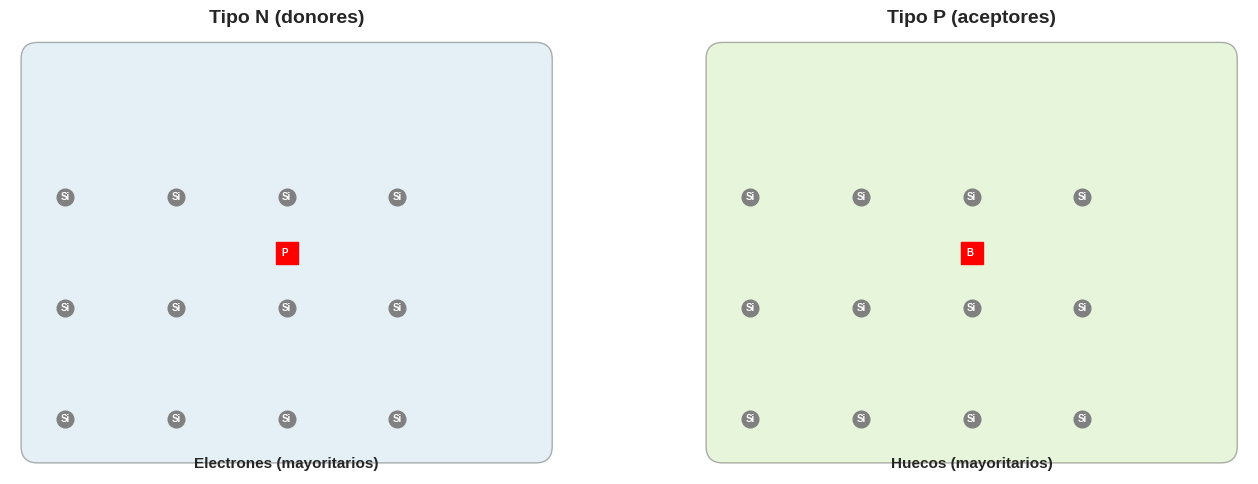

In [2]:
# Diagrama de estructura de semiconductores tipo N y tipo P
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tipo, color, dopante, portador in zip(
    axes,
    ['Tipo N (donores)', 'Tipo P (aceptores)'],
    [COLOR_N, COLOR_P],
    ['P (col. V)', 'B (col. III)'],
    ['Electrones (mayoritarios)', 'Huecos (mayoritarios)']
):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.set_title(tipo, fontsize=14, fontweight='bold')
    ax.axis('off')
    
    # Fondo cristal
    rect = FancyBboxPatch((0.5, 0.5), 9, 7, boxstyle='round,pad=0.3',
                          facecolor=color, edgecolor='black', alpha=0.3)
    ax.add_patch(rect)
    
    # Atomos Si en red
    for i in range(1, 9, 2):
        for j in range(1, 7, 2):
            ax.plot(i, j, 'o', color='gray', ms=12, zorder=3)
            ax.text(i, j, 'Si', ha='center', va='center', fontsize=7, zorder=4, color='white', fontweight='bold')
    
    # Dopante
    ax.plot(5, 4, 's', color='red', ms=16, zorder=5)
    ax.text(5, 4, dopante[:2], ha='center', va='center', fontsize=7, zorder=6, color='white', fontweight='bold')
    
    ax.text(5, 0.1, portador, ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 2. La unión PN

### 2.1 Formación de la zona de depleción

Cuando se une un semiconductor tipo P con uno tipo N, se produce una **difusión** de portadores mayoritarios a través de la unión:
- Electrones del lado N difunden hacia P
- Huecos del lado P difunden hacia N

Esto deja iones fijos (cargas no compensadas) que crean un **campo eléctrico interno** $\vec{E}$ que se opone a la difusión. Se establece una **zona de carga espacial** (zona de depleción) donde no hay portadores libres.

**Equilibrio:** La corriente de difusión y la corriente de arrastre se anulan mutuamente.

### 2.2 Polarización de la unión PN

| Polarización | $V_D$ | Zona depleción | Corriente $I_D$ |
|-------------|-------|----------------|------------------|
| **Directa** | $V_D > 0$ | Se estrecha | Grande, $I_D > 0$ |
| **Inversa** | $V_D < 0$ | Se ensancha | Muy pequeña, $I_D \approx -I_o$ |
| **Ruptura** | $V_D < -V_Z$ | Avalancha/Zener | Grande en inversa |

### 2.3 Ecuación de Shockley

$$\boxed{I_D = I_o \left( e^{V_D / \varphi_T} - 1 \right)}$$

donde:
- $I_o$: corriente de saturación inversa (típico $10^{-12}$ a $10^{-15}$ A para Si)
- $\varphi_T = \dfrac{kT}{q} \approx 0.025\;\text{V}$ a 300 K (potencial térmico)

**Con factor de idealidad** $\eta$:

$$I_D = I_o \left( e^{V_D / (\eta \varphi_T)} - 1 \right)$$

- $\eta = 1$ para Ge (corrientes bajas)
- $\eta = 2$ para Si (corrientes altas, recombinación en zona depleción)

### 2.4 Capacitancias parásitas

- **$C_T$ (transición):** debida a la zona de depleción (como un condensador de placas paralelas). Dominante en inversa.
- **$C_D$ (difusión):** debida a los portadores almacenados en directa. Dominante en directa.

---

## 3. El Diodo

### 3.1 Estructura y símbolo

El diodo es un dispositivo de **dos terminales** formado por una unión PN:
- **Ánodo (A):** terminal conectado al lado P
- **Cátodo (K):** terminal conectado al lado N

Convención de signos:
- $V_D$: tensión ánodo - cátodo (positiva en directa)
- $I_D$: corriente que entra por el ánodo (positiva en directa)

### 3.2 Curva característica

La curva $I_D$ vs $V_D$ tiene **tres regiones**:

1. **Conducción directa** ($V_D > V_T$): corriente crece exponencialmente
2. **Inversa** ($-V_Z < V_D < V_T$): corriente $\approx -I_o$ (despreciable)
3. **Ruptura** ($V_D < -V_Z$): corriente inversa muy grande

### 3.3 Parámetros característicos

| Parámetro | Símbolo | Valor típico (Si) | Descripción |
|-----------|---------|-------------------|-------------|
| Tensión umbral | $V_T$ | $\approx 0.5\;\text{V}$ | Inicio de conducción |
| Tensión directa | $V_F$ | $\approx 0.7\;\text{V}$ | Caída típica en conducción |
| Corriente inversa | $I_o$ | $10^{-12}$ - $10^{-15}\;\text{A}$ | Corriente de saturación |
| Tensión Zener | $V_Z$ | Variable | Tensión de ruptura |
| Potencia máx. | $P_{max}$ | Según encapsulado | Límite térmico |

### 3.4 Efecto de la temperatura

- $I_o$ se **duplica** cada 10°C de aumento
- $V_D$ disminuye $\approx -2.5\;\text{mV/°C}$ (a corriente constante)
- En resumen: **más caliente = conduce antes** (menor $V_F$)

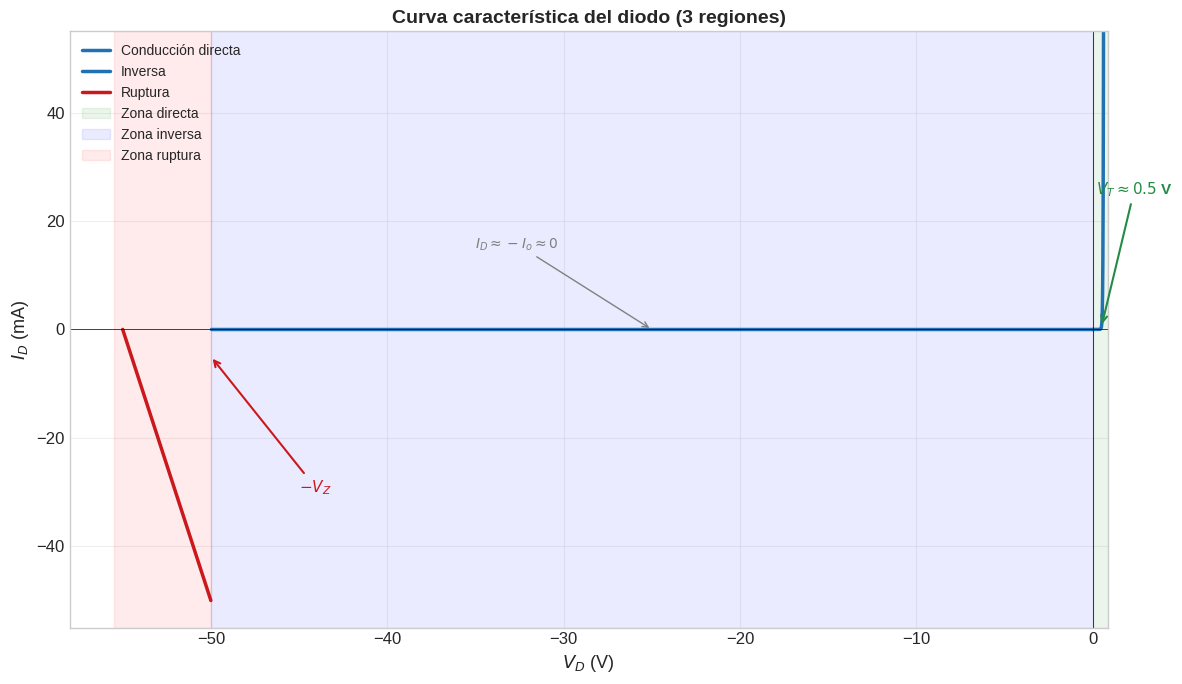

In [3]:
# Gráfica 1: Curva característica del diodo (3 regiones)
fig, ax = plt.subplots(figsize=(12, 7))

# Parámetros
Io = 1e-12  # A
phi_T = 0.025  # V
VZ = 50  # V (ruptura)

# Región directa
VD_dir = np.linspace(0, 0.8, 500)
ID_dir = Io * (np.exp(VD_dir / phi_T) - 1)
ID_dir_mA = ID_dir * 1e3

# Región inversa
VD_inv = np.linspace(-VZ, 0, 500)
ID_inv = Io * (np.exp(VD_inv / phi_T) - 1)
ID_inv_mA = ID_inv * 1e3

# Región de ruptura (modelo simplificado)
VD_rup = np.linspace(-VZ - 5, -VZ, 100)
ID_rup_mA = -np.linspace(0, 50, 100)

# Dibujar
ax.plot(VD_dir, ID_dir_mA, color=COLOR_PRINCIPAL, lw=2.5, label='Conducci\u00f3n directa')
ax.plot(VD_inv, ID_inv_mA, color=COLOR_PRINCIPAL, lw=2.5, label='Inversa')
ax.plot(VD_rup, ID_rup_mA, color=COLOR_RECTA, lw=2.5, label='Ruptura')

# Zonas de color
ax.axvspan(0, 0.85, alpha=0.08, color='green', label='Zona directa')
ax.axvspan(-VZ, 0, alpha=0.08, color='blue', label='Zona inversa')
ax.axvspan(-VZ - 5.5, -VZ, alpha=0.08, color='red', label='Zona ruptura')

# Marcas
ax.axhline(y=0, color='black', lw=0.5)
ax.axvline(x=0, color='black', lw=0.5)

# Anotaciones
ax.annotate(r'$V_T \approx 0.5$ V', xy=(0.5, 0.5), xytext=(0.2, 25),
            fontsize=11, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))

ax.annotate(r'$-V_Z$', xy=(-VZ, -5), xytext=(-VZ + 5, -30),
            fontsize=11, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1.5))

ax.annotate(r'$I_D \approx -I_o \approx 0$', xy=(-25, -0.0001), xytext=(-35, 15),
            fontsize=10, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.set_xlabel(r'$V_D$ (V)')
ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title('Curva caracter\u00edstica del diodo (3 regiones)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(-58, 0.85)
ax.set_ylim(-55, 55)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

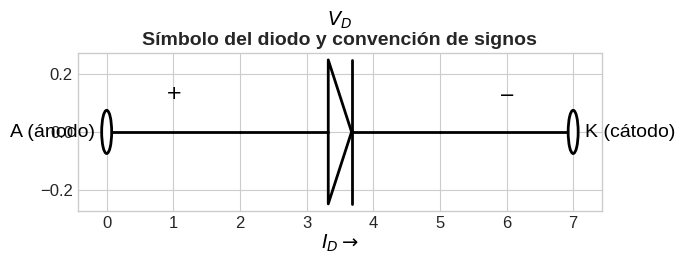

In [4]:
# Símbolo del diodo con schemdraw
fig, ax = plt.subplots(figsize=(7, 3))
ax.set_title('S\u00edmbolo del diodo y convenci\u00f3n de signos', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.Line().right().length(2).label(r'$+$', loc='top')
d += elm.Diode().right().label(r'$V_D$', loc='top').label(r'$I_D \rightarrow$', loc='bottom')
d += elm.Line().right().length(2).label(r'$-$', loc='top')
d += elm.Dot(open=True).label('K (c\u00e1todo)', loc='right')
d.here = d.elements[0].start
d += elm.Dot(open=True).label('A (\u00e1nodo)', loc='left')
d.draw()
plt.tight_layout()
plt.show()

---

## 4. Modelos linealizados de gran señal

Para resolver circuitos a mano, sustituimos la curva exponencial del diodo por **modelos lineales** de complejidad creciente.

### Modelo 1: Diodo con $V_F > 0$ (el más usado)

| Estado | Modelo |
|--------|--------|
| **Conducción** ($I_D > 0$) | $V_D = V_F$ (fuente de tensión, típ. 0.7 V para Si) |
| **Corte** ($V_D < V_F$) | $I_D = 0$ (circuito abierto) |
| **Ruptura** ($V_D < -V_Z$) | $V_D = -V_Z$ |

### Modelo 2: Diodo ideal ($V_F = 0$)

| Estado | Modelo |
|--------|--------|
| **Conducción** ($I_D > 0$) | $V_D = 0$ (cortocircuito) |
| **Corte** ($V_D < 0$) | $I_D = 0$ (circuito abierto) |

### Modelo 3: Diodo con $V_F > 0$ y resistencia serie $R_S$

| Estado | Modelo |
|--------|--------|
| **Conducción** ($I_D > 0$) | $V_D = V_F + I_D \cdot R_S$ |
| **Corte** ($V_D < V_F$) | $I_D = 0$ (circuito abierto) |

**Error frecuente:** Confundir $V_T$ (umbral, $\approx 0.5$ V) con $V_F$ (caída en conducción, $\approx 0.7$ V). En los modelos linealizados usamos $V_F$.

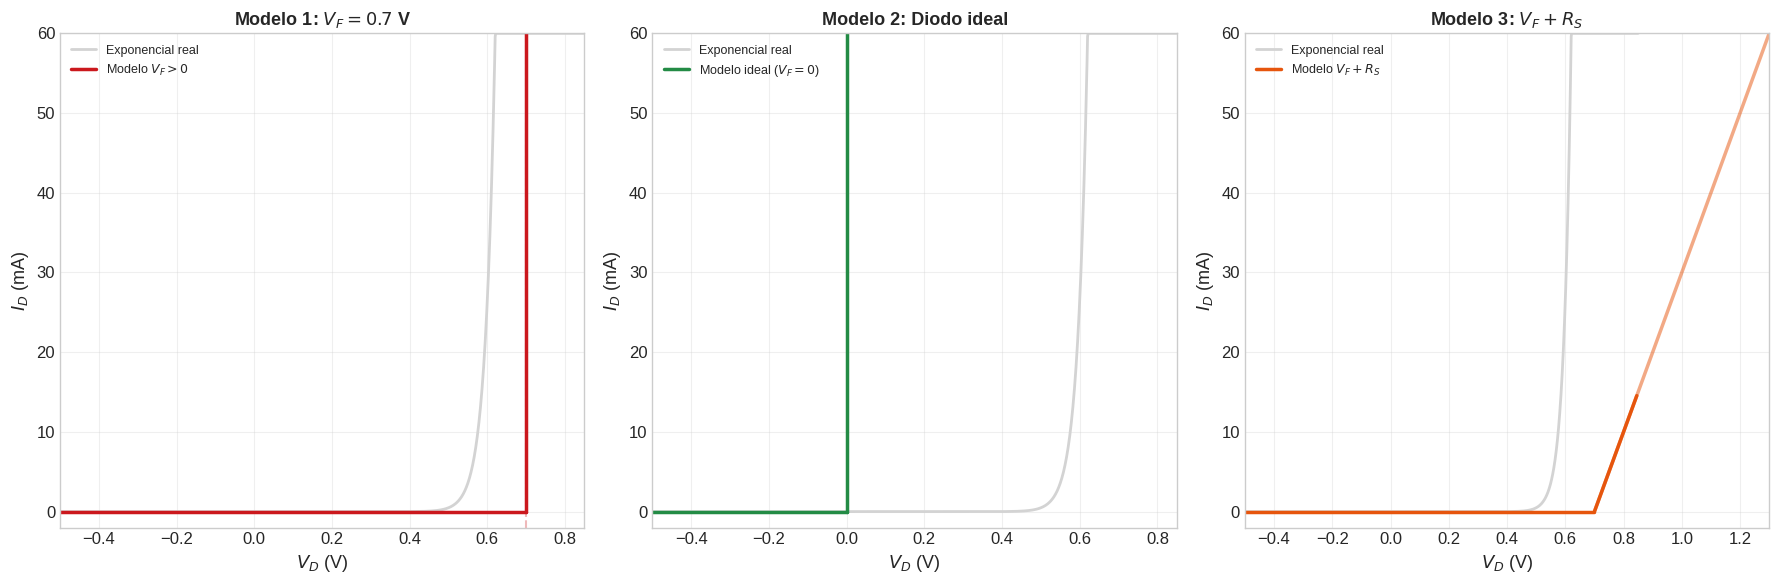

In [5]:
# Gráfica 2: Tres modelos linealizados superpuestos a la exponencial
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Curva exponencial de referencia
Io = 1e-12
phi_T = 0.025
VD_exp = np.linspace(-0.5, 0.85, 1000)
ID_exp = Io * (np.exp(np.clip(VD_exp / phi_T, -50, 30)) - 1) * 1e3  # mA
ID_exp = np.clip(ID_exp, -0.1, 60)

VF = 0.7  # V
RS = 10   # Ohm

# Modelo 1: VF > 0
ax = axes[0]
ax.plot(VD_exp, ID_exp, color='lightgray', lw=2, label='Exponencial real')
# Corte: ID = 0 para VD < VF
ax.plot([-0.5, VF], [0, 0], color=COLOR_RECTA, lw=2.5)
# Conducción: VD = VF, vertical
ax.plot([VF, VF], [0, 60], color=COLOR_RECTA, lw=2.5, label=r'Modelo $V_F > 0$')
ax.axvline(x=VF, color=COLOR_RECTA, ls='--', alpha=0.3)
ax.set_xlabel(r'$V_D$ (V)')
ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title(r'Modelo 1: $V_F = 0.7$ V', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.5, 0.85)
ax.set_ylim(-2, 60)
ax.grid(True, alpha=0.3)

# Modelo 2: Ideal (VF = 0)
ax = axes[1]
ax.plot(VD_exp, ID_exp, color='lightgray', lw=2, label='Exponencial real')
ax.plot([-0.5, 0], [0, 0], color=COLOR_PUNTO, lw=2.5)
ax.plot([0, 0], [0, 60], color=COLOR_PUNTO, lw=2.5, label=r'Modelo ideal ($V_F = 0$)')
ax.set_xlabel(r'$V_D$ (V)')
ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title(r'Modelo 2: Diodo ideal', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.5, 0.85)
ax.set_ylim(-2, 60)
ax.grid(True, alpha=0.3)

# Modelo 3: VF + RS
ax = axes[2]
ax.plot(VD_exp, ID_exp, color='lightgray', lw=2, label='Exponencial real')
ax.plot([-0.5, VF], [0, 0], color='#e6550d', lw=2.5)
# Línea con pendiente 1/RS desde (VF, 0)
ID_rs = np.linspace(0, 60, 100)
VD_rs = VF + ID_rs * 1e-3 * RS  # VF + ID*RS
mask = VD_rs <= 0.85
ax.plot(VD_rs[mask], ID_rs[mask], color='#e6550d', lw=2.5, label=r'Modelo $V_F + R_S$')
ax.plot(VD_rs, ID_rs, color='#e6550d', lw=2.5, alpha=0.5)
ax.set_xlabel(r'$V_D$ (V)')
ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title(r'Modelo 3: $V_F + R_S$', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.5, 1.3)
ax.set_ylim(-2, 60)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Análisis de circuitos con diodos

### 5.1 Punto de operación

El **punto de operación** (Q) es la intersección entre:
- La **curva del diodo**: $I_D = I_o(e^{V_D/\varphi_T} - 1)$
- La **recta de carga**: $I_D = -\dfrac{V_D}{R} + \dfrac{V_{CC}}{R}$

La recta de carga se obtiene por KVL en el circuito: $V_{CC} = R \cdot I_D + V_D$

### 5.2 Métodos de resolución

1. **Exacto (exponencial):** Resolver $I_o(e^{V_D/\varphi_T} - 1) = (V_{CC} - V_D)/R$ (ecuación trascendente, necesita métodos numéricos)
2. **Simulación (SPICE):** El ordenador resuelve iterativamente
3. **Modelos linealizados:** Sustituir el diodo por su modelo y resolver el circuito lineal resultante

### 5.3 Metodología de 5 pasos (FUNDAMENTAL)

$$\boxed{\text{1. Suponer estado} \to \text{2. Sustituir modelo} \to \text{3. Resolver} \to \text{4. Verificar} \to \text{5. Repetir si falla}}$$

**Paso 1:** Suponer que el diodo conduce ($I_D > 0$, $V_D = V_F$)

**Paso 2:** Sustituir el diodo por una fuente de tensión $V_F$

**Paso 3:** Resolver el circuito lineal (KVL, KCL)

**Paso 4:** Verificar que $I_D > 0$. Si se cumple, la hipótesis es correcta

**Paso 5:** Si $I_D < 0$, la hipótesis falla. Suponer corte ($I_D = 0$, circuito abierto) y resolver de nuevo

> **Truco para el examen:** Si hay varios diodos, empieza suponiendo que todos conducen. Es más rápido que adivinar cuál está en corte.

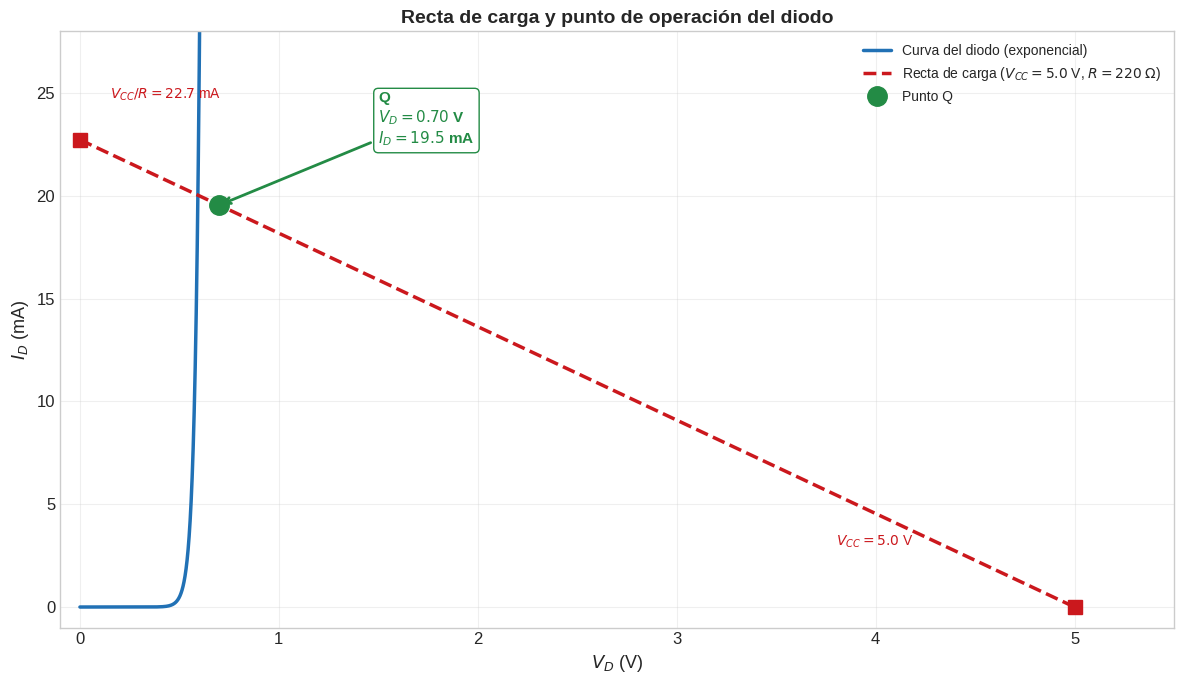

In [6]:
# Gráfica 3: Recta de carga intersecando con la exponencial
fig, ax = plt.subplots(figsize=(12, 7))

# Curva exponencial
Io = 1e-12
phi_T = 0.025
VD = np.linspace(0, 0.85, 1000)
ID = Io * (np.exp(np.clip(VD / phi_T, -50, 30)) - 1) * 1e3
ID = np.clip(ID, 0, 30)

ax.plot(VD, ID, color=COLOR_PRINCIPAL, lw=2.5, label='Curva del diodo (exponencial)')

# Recta de carga: ID = -VD/R + VCC/R
VCC = 5.0  # V
R = 220     # Ohm
VD_recta = np.linspace(0, VCC, 100)
ID_recta = (-VD_recta / R + VCC / R) * 1e3  # mA

ax.plot(VD_recta, ID_recta, color=COLOR_RECTA, lw=2.5, ls='--',
        label=f'Recta de carga ($V_{{CC}}={VCC}$ V, $R={R}$ $\\Omega$)')

# Punto de operación aproximado (VD ~ 0.7V)
VD_Q = 0.70
ID_Q = (VCC - VD_Q) / R * 1e3
ax.plot(VD_Q, ID_Q, 'o', color=COLOR_PUNTO, ms=14, zorder=5, label='Punto Q')
ax.annotate(f'Q\n$V_D={VD_Q:.2f}$ V\n$I_D={ID_Q:.1f}$ mA',
            xy=(VD_Q, ID_Q), xytext=(VD_Q + 0.8, ID_Q + 3),
            fontsize=11, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

# Puntos de corte
ax.plot(0, VCC / R * 1e3, 's', color=COLOR_RECTA, ms=10)
ax.annotate(f'$V_{{CC}}/R = {VCC/R*1e3:.1f}$ mA',
            xy=(0, VCC / R * 1e3), xytext=(0.15, VCC / R * 1e3 + 2),
            fontsize=10, color=COLOR_RECTA)
ax.plot(VCC, 0, 's', color=COLOR_RECTA, ms=10)
ax.annotate(f'$V_{{CC}} = {VCC}$ V',
            xy=(VCC, 0), xytext=(VCC - 1.2, 3),
            fontsize=10, color=COLOR_RECTA)

ax.set_xlabel(r'$V_D$ (V)')
ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title('Recta de carga y punto de operaci\u00f3n del diodo', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(-0.1, 5.5)
ax.set_ylim(-1, 28)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

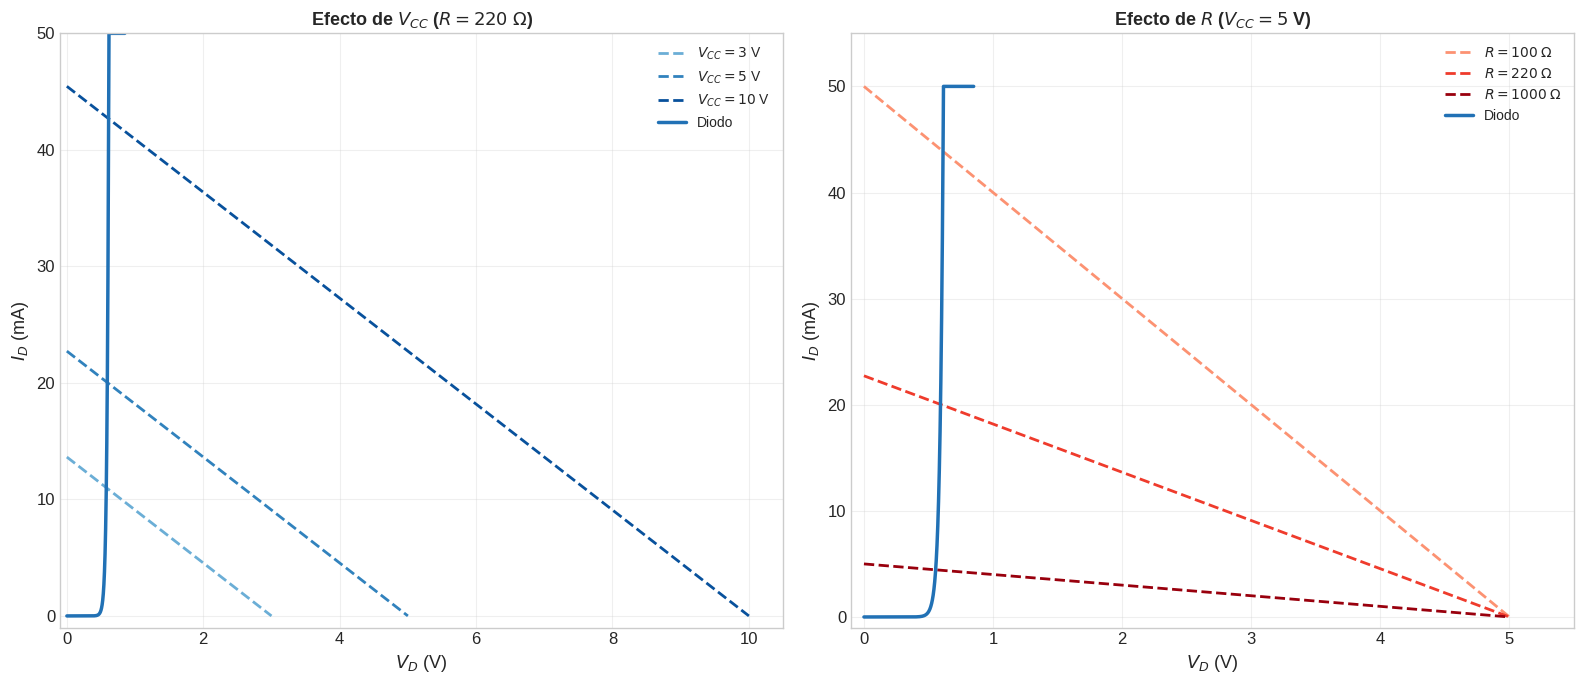

In [7]:
# Gráfica 4: Efecto de VCC y R en la recta de carga
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Curva exponencial base
VD = np.linspace(0, 0.85, 1000)
ID = Io * (np.exp(np.clip(VD / phi_T, -50, 30)) - 1) * 1e3
ID = np.clip(ID, 0, 50)

# Efecto de VCC (R fijo)
ax = axes[0]
R_fijo = 220
colores_vcc = ['#6baed6', '#3182bd', '#08519c']
for VCC_val, color in zip([3, 5, 10], colores_vcc):
    VD_r = np.linspace(0, VCC_val, 100)
    ID_r = (-VD_r / R_fijo + VCC_val / R_fijo) * 1e3
    ax.plot(VD_r, ID_r, color=color, lw=2, ls='--',
            label=f'$V_{{CC}} = {VCC_val}$ V')

ax.plot(VD, ID, color=COLOR_PRINCIPAL, lw=2.5, label='Diodo')
ax.set_xlabel(r'$V_D$ (V)')
ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title(f'Efecto de $V_{{CC}}$ ($R = {R_fijo}\\;\\Omega$)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-0.1, 10.5)
ax.set_ylim(-1, 50)
ax.grid(True, alpha=0.3)

# Efecto de R (VCC fijo)
ax = axes[1]
VCC_fijo = 5
colores_r = ['#fc9272', '#ef3b2c', '#99000d']
for R_val, color in zip([100, 220, 1000], colores_r):
    VD_r = np.linspace(0, VCC_fijo, 100)
    ID_r = (-VD_r / R_val + VCC_fijo / R_val) * 1e3
    ax.plot(VD_r, ID_r, color=color, lw=2, ls='--',
            label=f'$R = {R_val}\\;\\Omega$')

ax.plot(VD, ID, color=COLOR_PRINCIPAL, lw=2.5, label='Diodo')
ax.set_xlabel(r'$V_D$ (V)')
ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title(f'Efecto de $R$ ($V_{{CC}} = {VCC_fijo}$ V)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-0.1, 5.5)
ax.set_ylim(-1, 55)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 6. Tipos de diodos

| Tipo | Característica principal | $V_F$ típica | Aplicación |
|------|-------------------------|------------|------------|
| **Rectificador** | Unión PN estándar | $0.7\;\text{V}$ (Si) | Rectificación de AC a DC |
| **Zener** | Diseñado para operar en ruptura | $V_Z$ (2.4 - 200 V) | Regulación de tensión |
| **Schottky** | Unión metal-semiconductor | $\approx 0.2\;\text{V}$ | Conmutación rápida |
| **LED** | Emite luz en directa | 1.8 - 3.5 V (según color) | Indicación, iluminación |
| **PIN fotodiodo** | Detecta luz en inversa | - | Comunicaciones ópticas |
| **APD** | Fotodiodo con ganancia de avalancha | - | Detección débil |

**Diodo Zener:** En polarización inversa, cuando $V_D < -V_Z$, el diodo entra en ruptura controlada. La tensión $V_Z$ se mantiene aproximadamente constante. Esto lo hace ideal para **regulación de tensión**.

**LED:** La tensión directa depende del color (energía del fotón emitido):
- Rojo: $\approx 1.8$ V
- Verde: $\approx 2.2$ V
- Azul: $\approx 3.3$ V

---

# PARTE 2: Aplicaciones del Diodo (Tema 3)

---

## 7. Rectificación de ondas: parámetros de señal

Antes de analizar los circuitos rectificadores, definimos los parámetros clave de cualquier señal periódica:

| Parámetro | Símbolo | Fórmula general |
|-----------|---------|------------------|
| Valor medio (DC) | $V_m$ o $V_{DC}$ | $\dfrac{1}{T}\int_0^T v(t)\,dt$ |
| Valor eficaz (RMS) | $V_{ef}$ | $\sqrt{\dfrac{1}{T}\int_0^T v^2(t)\,dt}$ |
| Valor pico a pico | $V_{pp}$ | $v_{max} - v_{min}$ |
| Factor de rizado | $f_r$ | $\dfrac{V_{pp}}{V_{DC}} \times 100\%$ |

**Para una sinusoide** $v(t) = V_p \sin(2\pi f t)$:

$$V_{DC} = 0 \qquad V_{ef} = \frac{V_p}{\sqrt{2}} \qquad V_{pp} = 2V_p \qquad f_r = \text{no definido}$$

---

## 8. Rectificador de media onda

### 8.1 Circuito

Fuente AC $\to$ Diodo $\to$ Resistencia $R$

El diodo solo deja pasar el semiciclo positivo.

### 8.2 Análisis con diodo ideal ($V_F = 0$)

$$\boxed{V_{DC} = \frac{V_p}{\pi}} \qquad V_{ef} = \frac{V_p}{2} \qquad V_{pp} = V_p \qquad f_r = \frac{V_p}{V_p/\pi} = \pi = 314\%$$

### 8.3 Con diodo real ($V_F = 0.7$ V)

La salida se reduce en $V_F$. El pico de salida es $V_p - V_F$:

$$V_{DC} = \frac{V_p - V_F}{\pi}$$

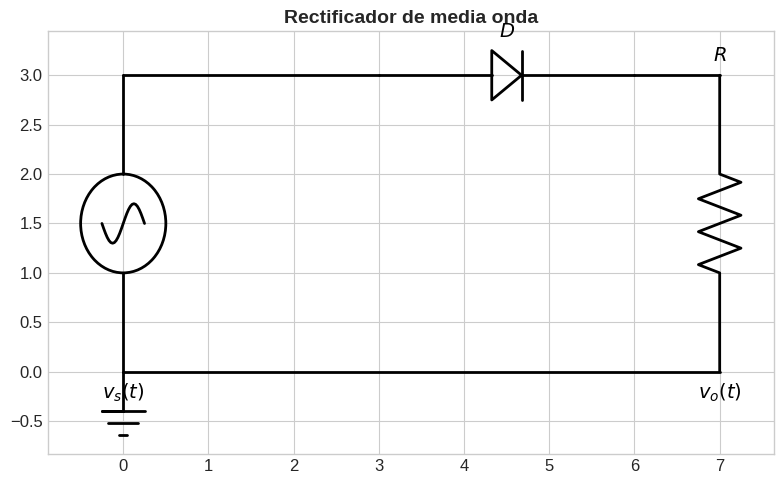

In [8]:
# Circuito rectificador de media onda con schemdraw
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title('Rectificador de media onda', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceSin().up().label(r'$v_s(t)$', loc='left')
d += elm.Line().right().length(3)
d += elm.Diode().right().label(r'$D$', loc='top')
d += elm.Line().right().length(1)
d += elm.Resistor().down().label(r'$R$', loc='right').label(r'$v_o(t)$', loc='left')
d += elm.Line().left().length(7)
d += elm.Ground()
d.draw()
plt.tight_layout()
plt.show()

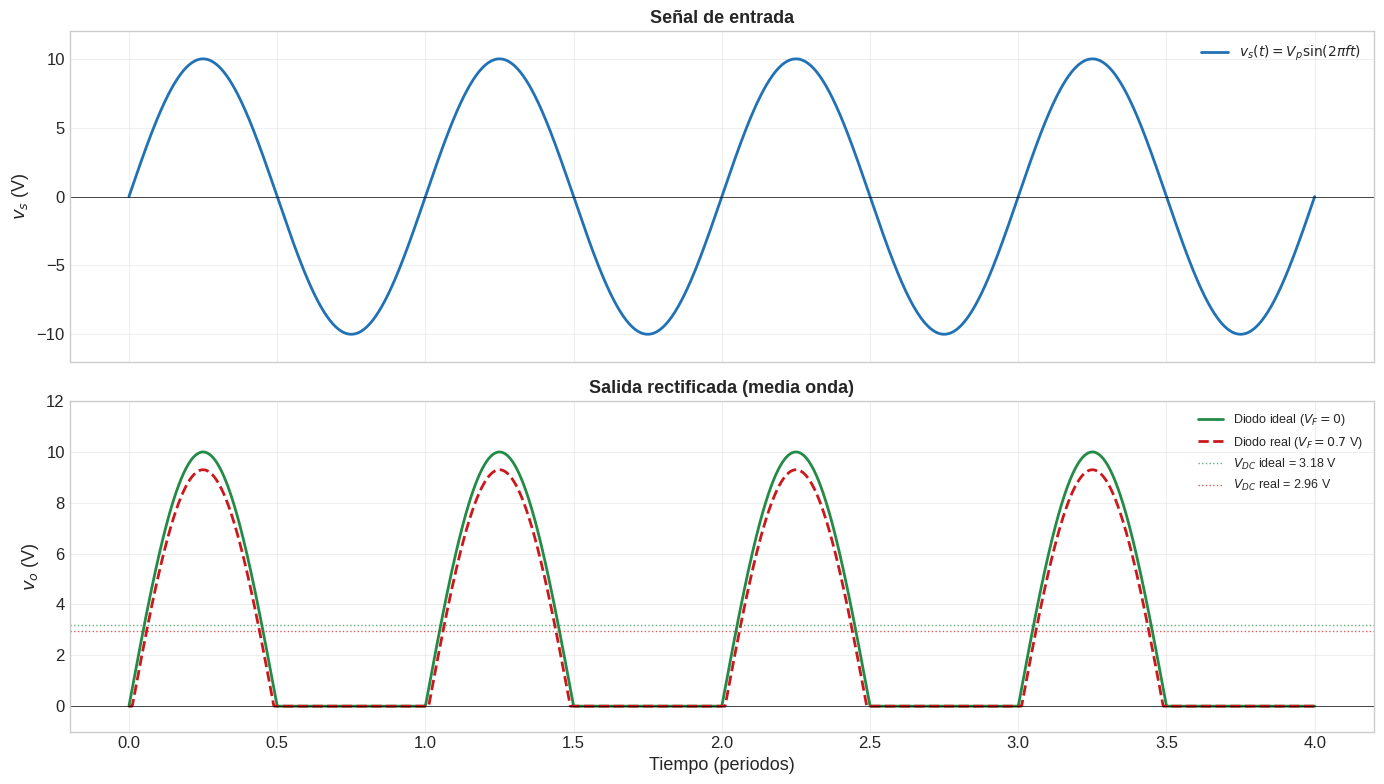

In [9]:
# Gráfica 5: Forma de onda - rectificación de media onda
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

t = np.linspace(0, 4, 2000)  # 4 periodos
f = 1  # Hz (normalizado)
Vp = 10  # V
VF = 0.7

vs = Vp * np.sin(2 * np.pi * f * t)

# Salida media onda (ideal)
vo_ideal = np.maximum(vs, 0)

# Salida media onda (real)
vo_real = np.maximum(vs - VF, 0)

# Entrada
ax = axes[0]
ax.plot(t, vs, color=COLOR_PRINCIPAL, lw=2, label=r'$v_s(t) = V_p \sin(2\pi f t)$')
ax.axhline(y=0, color='black', lw=0.5)
ax.set_ylabel(r'$v_s$ (V)')
ax.set_title('Se\u00f1al de entrada', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-12, 12)
ax.grid(True, alpha=0.3)

# Salida
ax = axes[1]
ax.plot(t, vo_ideal, color=COLOR_PUNTO, lw=2, label=r'Diodo ideal ($V_F = 0$)')
ax.plot(t, vo_real, color=COLOR_RECTA, lw=2, ls='--', label=r'Diodo real ($V_F = 0.7$ V)')
ax.axhline(y=Vp/np.pi, color=COLOR_PUNTO, lw=1, ls=':', alpha=0.7, label=f'$V_{{DC}}$ ideal = {Vp/np.pi:.2f} V')
ax.axhline(y=(Vp - VF)/np.pi, color=COLOR_RECTA, lw=1, ls=':', alpha=0.7, label=f'$V_{{DC}}$ real = {(Vp-VF)/np.pi:.2f} V')
ax.axhline(y=0, color='black', lw=0.5)
ax.set_xlabel('Tiempo (periodos)')
ax.set_ylabel(r'$v_o$ (V)')
ax.set_title('Salida rectificada (media onda)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(-1, 12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 9. Rectificador de onda completa (puente)

### 9.1 Circuito

Se usan **4 diodos en puente** (puente de Graetz). En cada semiciclo conducen 2 diodos:

- **Semiciclo positivo** ($v_s > 0$): conducen $D_1$ y $D_3$
- **Semiciclo negativo** ($v_s < 0$): conducen $D_2$ y $D_4$

La corriente siempre circula en el **mismo sentido** por la carga $R$.

### 9.2 Análisis con diodo ideal

$$\boxed{V_{DC} = \frac{2V_p}{\pi}} \qquad V_{ef} = \frac{V_p}{\sqrt{2}} \qquad V_{pp} = V_p \qquad f_r = \frac{V_p}{2V_p/\pi} = \frac{\pi}{2} = 157\%$$

### 9.3 Con diodo real

En cada semiciclo hay **2 diodos en serie**, por lo que la salida se reduce en $2V_F$:

$$V_{DC} = \frac{2(V_p - 2V_F)}{\pi}$$

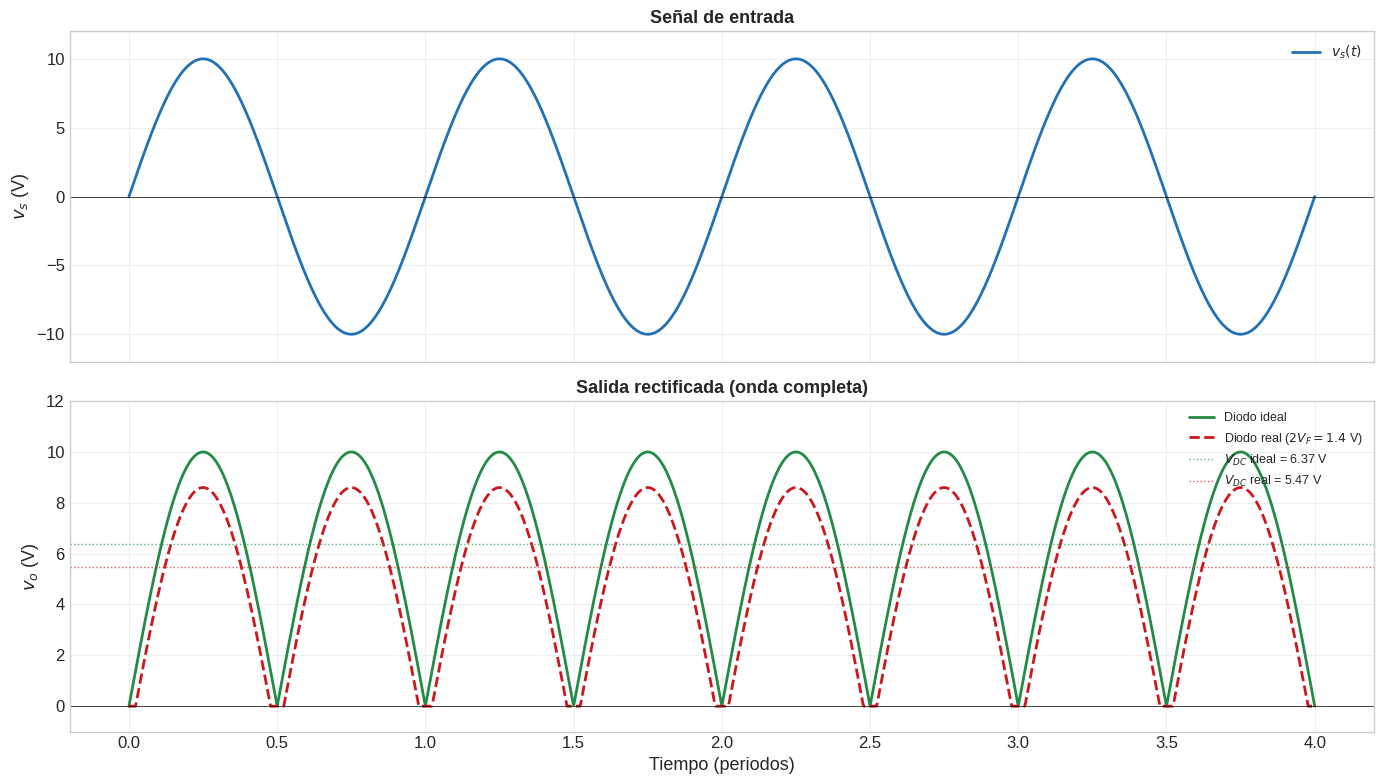

In [10]:
# Gráfica 6: Forma de onda - rectificación de onda completa
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

t = np.linspace(0, 4, 2000)
f = 1
Vp = 10
VF = 0.7

vs = Vp * np.sin(2 * np.pi * f * t)

# Salida onda completa
vo_ideal = np.abs(vs)
vo_real = np.maximum(np.abs(vs) - 2 * VF, 0)

# Entrada
ax = axes[0]
ax.plot(t, vs, color=COLOR_PRINCIPAL, lw=2, label=r'$v_s(t)$')
ax.axhline(y=0, color='black', lw=0.5)
ax.set_ylabel(r'$v_s$ (V)')
ax.set_title('Se\u00f1al de entrada', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-12, 12)
ax.grid(True, alpha=0.3)

# Salida
ax = axes[1]
ax.plot(t, vo_ideal, color=COLOR_PUNTO, lw=2, label=r'Diodo ideal')
ax.plot(t, vo_real, color=COLOR_RECTA, lw=2, ls='--', label=r'Diodo real ($2V_F = 1.4$ V)')
VDC_ideal = 2 * Vp / np.pi
VDC_real = 2 * (Vp - 2 * VF) / np.pi
ax.axhline(y=VDC_ideal, color=COLOR_PUNTO, lw=1, ls=':', alpha=0.7,
           label=f'$V_{{DC}}$ ideal = {VDC_ideal:.2f} V')
ax.axhline(y=VDC_real, color=COLOR_RECTA, lw=1, ls=':', alpha=0.7,
           label=f'$V_{{DC}}$ real = {VDC_real:.2f} V')
ax.axhline(y=0, color='black', lw=0.5)
ax.set_xlabel('Tiempo (periodos)')
ax.set_ylabel(r'$v_o$ (V)')
ax.set_title('Salida rectificada (onda completa)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(-1, 12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 10. Rectificador con condensador (filtro)

### 10.1 Funcionamiento

Se añade un **condensador $C$ en paralelo con $R$** para suavizar la salida.

**Fase de carga:** Cuando $v_s > v_C$, el diodo conduce y el condensador se carga rápidamente siguiendo a la fuente.

**Fase de descarga:** Cuando $v_s < v_C$, el diodo entra en corte y el condensador se descarga a través de $R$ con constante de tiempo $\tau = RC$.

### 10.2 Efectos del filtrado

- $V_{DC}$ **aumenta** (se acerca a $V_p$)
- $V_{pp}$ **disminuye** (menor rizado)
- $f_r$ **disminuye** (mejor calidad DC)

### 10.3 Aproximación para el rizado (media onda)

Si $RC \gg T$ (descarga lenta):

$$\boxed{V_{pp} \approx \frac{V_p}{f \cdot R \cdot C}}$$

$$V_{DC} \approx V_p - \frac{V_{pp}}{2} = V_p - \frac{V_p}{2fRC}$$

Para onda completa, la frecuencia de rizado es $2f$, por lo que:

$$V_{pp,\text{completa}} \approx \frac{V_p}{2f \cdot R \cdot C}$$

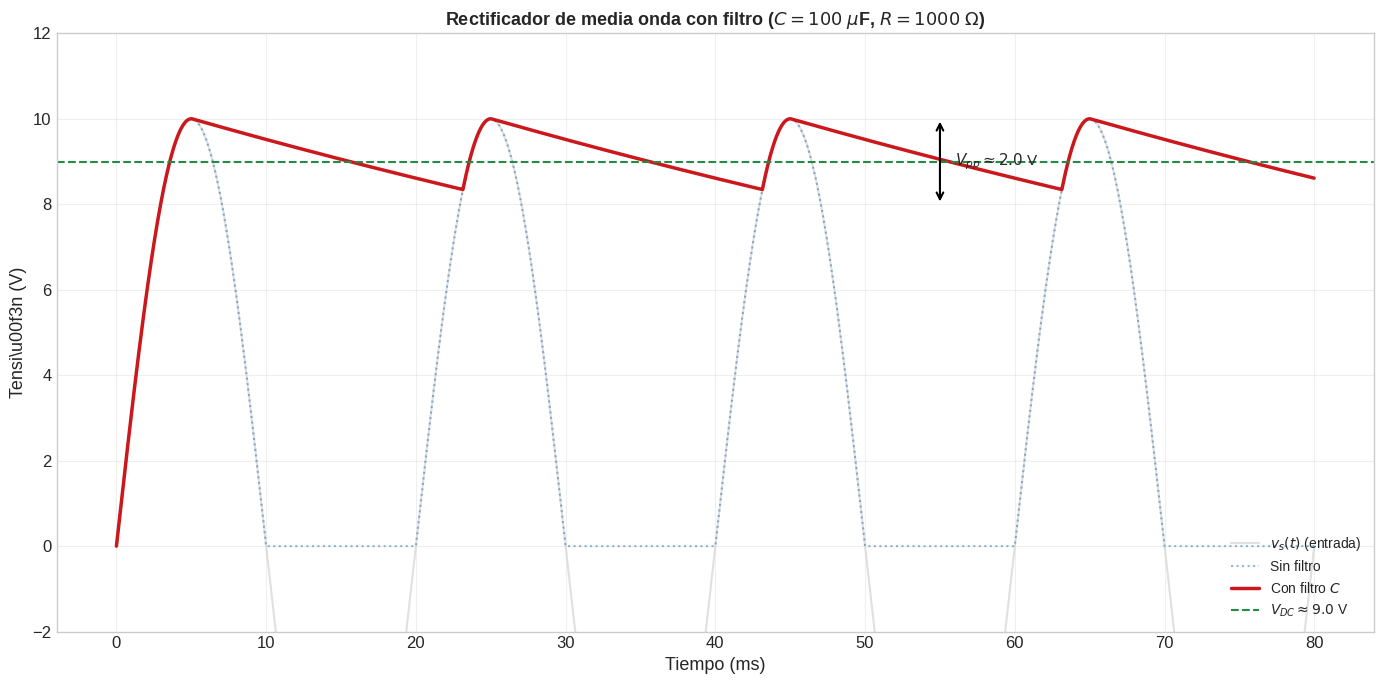

In [11]:
# Gráfica 7: Rectificador con condensador (filtrado)
fig, ax = plt.subplots(figsize=(14, 7))

# Parámetros
Vp = 10
f = 50   # Hz
T = 1/f
R = 1000  # Ohm
C = 100e-6  # F
tau = R * C
dt = 1e-5
t_total = 4 * T
t = np.arange(0, t_total, dt)

vs = Vp * np.sin(2 * np.pi * f * t)

# Simulación de carga/descarga del condensador
vc = np.zeros_like(t)
vc[0] = 0

for i in range(1, len(t)):
    if vs[i] > vc[i-1]:
        # Diodo conduce: condensador se carga
        vc[i] = vs[i]
    else:
        # Diodo en corte: descarga exponencial
        vc[i] = vc[i-1] * np.exp(-dt / tau)

# Señal sin filtro (media onda)
vo_sin = np.maximum(vs, 0)

# Dibujar
ax.plot(t * 1e3, vs, color='lightgray', lw=1.5, label=r'$v_s(t)$ (entrada)', alpha=0.7)
ax.plot(t * 1e3, vo_sin, color=COLOR_PRINCIPAL, lw=1.5, ls=':', alpha=0.5, label='Sin filtro')
ax.plot(t * 1e3, vc, color=COLOR_RECTA, lw=2.5, label=r'Con filtro $C$')

# Rizado teórico
Vpp_teo = Vp / (f * R * C)
VDC_teo = Vp - Vpp_teo / 2
ax.axhline(y=VDC_teo, color=COLOR_PUNTO, ls='--', lw=1.5,
           label=f'$V_{{DC}} \\approx {VDC_teo:.1f}$ V')

# Anotación del rizado
ax.annotate('', xy=(55, Vp), xytext=(55, Vp - Vpp_teo),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(56, Vp - Vpp_teo / 2, f'$V_{{pp}} \\approx {Vpp_teo:.1f}$ V',
        fontsize=11, va='center')

ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel(r'Tensi\u00f3n (V)')
ax.set_title(f'Rectificador de media onda con filtro ($C = {C*1e6:.0f}\\;\\mu$F, $R = {R}\\;\\Omega$)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(-2, 12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. El diodo Zener y la regulación de tensión

### 11.1 ¿Qué es un diodo Zener y en qué se diferencia de un diodo normal?

Un diodo Zener es un diodo **diseñado para funcionar en la zona de ruptura inversa** de forma controlada y segura. A diferencia de un diodo rectificador (que se destruye en ruptura), el Zener mantiene una **tensión prácticamente constante** $V_Z$ mientras la corriente que lo atraviesa esté dentro de sus límites.

**En directa**: se comporta exactamente como un diodo normal ($V_F \approx 0.7$ V).

**En inversa**: cuando la tensión inversa alcanza $V_Z$, el Zener "se enciende" y **fija la tensión** a $V_Z$ independientemente de la corriente (dentro de los límites).

### 11.2 ¿Qué significa "regular" tensión?

**Regular** = mantener la tensión de salida **constante** aunque cambien las condiciones externas:
- Que varíe la fuente de alimentación $V_{CC}$ (regulación de línea)
- Que varíe la carga $R_L$ (regulación de carga)

Sin regulador: si $V_{CC}$ sube, $V_{out}$ sube proporcionalmente. Con Zener: $V_{out} = V_Z$ = constante.

### 11.3 Las variables del circuito Zener y qué significa cada una

| Variable | Significado | Unidad |
|----------|-------------|--------|
| $V_Z$ | **Tensión Zener**: la tensión que el diodo mantiene constante en ruptura | V |
| $I_{ZK}$ | **Corriente mínima** (knee current): la mínima corriente para que el Zener regule. Si $I_Z < I_{ZK}$, el Zener no mantiene $V_Z$ constante | mA |
| $I_{ZM}$ | **Corriente máxima**: si $I_Z > I_{ZM}$, el Zener se destruye por exceso de potencia ($P = V_Z \cdot I_Z > P_{max}$) | mA |
| $R_S$ | **Resistencia serie** (o limitadora): protege al Zener de corriente excesiva. Absorbe la diferencia de tensión $V_{CC} - V_Z$ | $\Omega$ |
| $R_L$ | **Resistencia de carga**: el circuito que queremos alimentar con tensión regulada $V_Z$ | $\Omega$ |
| $I_{R_S}$ | Corriente que circula por $R_S$: toda la corriente que viene de $V_{CC}$ | mA |
| $I_{R_L}$ | Corriente por la carga: $I_{R_L} = V_Z / R_L$ (constante mientras el Zener regula) | mA |
| $I_Z$ | Corriente por el Zener: lo que "sobra" después de alimentar la carga: $I_Z = I_{R_S} - I_{R_L}$ | mA |

### 11.4 ¿Cómo funciona la regulación? (paso a paso intuitivo)

**El truco**: el Zener actúa como una "válvula de escape" para la corriente sobrante.

1. La fuente $V_{CC}$ empuja corriente a través de $R_S$: $I_{R_S} = (V_{CC} - V_Z)/R_S$
2. La carga consume una corriente fija: $I_{R_L} = V_Z/R_L$
3. **Todo lo que sobra** se lo "traga" el Zener: $I_Z = I_{R_S} - I_{R_L}$

- Si $V_{CC}$ **sube** $\to$ $I_{R_S}$ sube $\to$ pero $I_{R_L}$ no cambia (porque $V_Z$ es constante) $\to$ $I_Z$ sube $\to$ el Zener absorbe el exceso. **La carga no se entera.**
- Si $V_{CC}$ **baja** $\to$ $I_{R_S}$ baja $\to$ $I_Z$ baja $\to$ el Zener absorbe menos. Si baja demasiado, $I_Z < I_{ZK}$ y pierde la regulación.

### 11.5 Las tres zonas de funcionamiento

| Zona | Condición | ¿Regula? | $V_{out}$ |
|------|-----------|----------|-----------|
| **Zener OFF** | $V_{CC} < V_Z$ o $I_Z < I_{ZK}$ | No | $V_{out} = V_{CC} \cdot R_L/(R_S+R_L)$ (divisor) |
| **Regulación** | $I_{ZK} \leq I_Z \leq I_{ZM}$ | **Sí** | $V_{out} = V_Z$ (constante) |
| **Destrucción** | $I_Z > I_{ZM}$ | No (se rompe) | $V_Z$ pero el Zener muere |

In [12]:
# Funcionamiento del diodo Zener: curva I-V y zonas
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Curva I-V del Zener ---
ax = axes[0]
VZ = 5.1; VF = 0.7; IZK = 1; IZM = 50

# Directa (como diodo normal)
v_fwd = np.linspace(0, 0.9, 100)
i_fwd = 1e-14 * (np.exp(v_fwd / 0.026) - 1) * 1e3
i_fwd = np.clip(i_fwd, 0, 60)

# Inversa (antes de ruptura)
v_rev = np.linspace(-VZ, 0, 50)
i_rev = np.zeros_like(v_rev) - 0.01

# Zona Zener (ruptura controlada)
v_zen = np.linspace(-VZ-0.5, -VZ, 50)
i_zen = np.linspace(-IZM, -IZK, 50)

ax.plot(v_fwd, i_fwd, color=COLOR_PRINCIPAL, lw=2.5)
ax.plot(v_rev, i_rev, color=COLOR_PRINCIPAL, lw=2.5)
ax.plot(v_zen, i_zen, color=COLOR_RECTA, lw=3, label='Zona Zener (regulación)')
ax.axhline(y=0, color='black', lw=0.5)
ax.axvline(x=0, color='black', lw=0.5)

# Anotaciones
ax.annotate(rf'$V_Z = {VZ}$ V', xy=(-VZ, -IZK), xytext=(-VZ+1.5, -15),
            fontsize=12, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1.5))
ax.axhline(y=-IZK, color='gray', ls=':', lw=1, alpha=0.7)
ax.axhline(y=-IZM, color='orange', ls=':', lw=1, alpha=0.7)
ax.text(-1.5, -IZK-3, rf'$I_{{ZK}} = {IZK}$ mA', fontsize=10, color='gray')
ax.text(-1.5, -IZM-3, rf'$I_{{ZM}} = {IZM}$ mA', fontsize=10, color='orange')
ax.fill_between([-VZ-0.5, -VZ], -IZM, -IZK, alpha=0.15, color='green')
ax.text(-VZ-0.25, -25, 'Zona\nde\nregulación', fontsize=10, color=COLOR_PUNTO,
        ha='center', fontweight='bold')

ax.set_xlabel(r'$V_D$ (V)'); ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title('Curva I-V del diodo Zener', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(-7, 1.2); ax.set_ylim(-55, 30)

# --- Diagrama de flujo de corrientes ---
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('Flujo de corrientes en el regulador', fontsize=13, fontweight='bold')

# VCC
ax.annotate('', xy=(2, 7), xytext=(0.5, 7),
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=3))
ax.text(1.25, 7.4, r'$I_{R_S}$', fontsize=14, color=COLOR_PRINCIPAL, ha='center', fontweight='bold')
ax.text(0.3, 7, r'$V_{CC}$', fontsize=13, ha='right', va='center', fontweight='bold')

# RS
from matplotlib.patches import FancyBboxPatch
ax.add_patch(FancyBboxPatch((2, 6.5), 2, 1, boxstyle='round,pad=0.1',
             facecolor='lightyellow', edgecolor='black', lw=1.5))
ax.text(3, 7, r'$R_S$', fontsize=14, ha='center', va='center', fontweight='bold')

# Nodo de bifurcación
ax.plot(5, 7, 'ko', ms=8, zorder=5)
ax.text(5, 7.5, 'Nodo', fontsize=10, ha='center', color='gray')

# Hacia RL (arriba-derecha)
ax.annotate('', xy=(7, 8.5), xytext=(5, 7),
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2.5))
ax.text(6.5, 8, r'$I_{R_L}$', fontsize=13, color=COLOR_PUNTO, fontweight='bold')
ax.add_patch(FancyBboxPatch((7, 8), 2.5, 1, boxstyle='round,pad=0.1',
             facecolor='lightgreen', edgecolor='black', lw=1.5))
ax.text(8.25, 8.5, r'$R_L$' + '\n(carga)', fontsize=12, ha='center', va='center')

# Hacia Zener (abajo-derecha)
ax.annotate('', xy=(7, 5.5), xytext=(5, 7),
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2.5))
ax.text(6.5, 6, r'$I_Z$', fontsize=13, color=COLOR_RECTA, fontweight='bold')
ax.add_patch(FancyBboxPatch((7, 5), 2.5, 1, boxstyle='round,pad=0.1',
             facecolor='#ffcccc', edgecolor='black', lw=1.5))
ax.text(8.25, 5.5, 'Zener\n' + rf'$V_Z={VZ}$ V', fontsize=12, ha='center', va='center')

# Ecuaciones
ax.text(5, 3.5, r'$I_{R_S} = I_{R_L} + I_Z$', fontsize=16, ha='center',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))
ax.text(5, 2.2, r'$I_{R_S} = \frac{V_{CC} - V_Z}{R_S}$' + '     ' +
        r'$I_{R_L} = \frac{V_Z}{R_L}$' + '     ' +
        r'$I_Z = I_{R_S} - I_{R_L}$', fontsize=12, ha='center', color='#555')
ax.text(5, 1, 'El Zener absorbe la corriente SOBRANTE.\n'
        'Si VCC sube, IZ sube pero VZ no cambia.',
        fontsize=11, ha='center', style='italic', color=COLOR_PUNTO)

plt.tight_layout(); plt.show()

ValueError: 
\boxed{I_{R_S} = I_{R_L} + I_Z}
^
ParseFatalException: Unknown symbol: \boxed, found '\'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x7853f1c00360> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
\boxed{I_{R_S} = I_{R_L} + I_Z}
^
ParseFatalException: Unknown symbol: \boxed, found '\'  (at char 0), (line:1, col:1)

ValueError: 
\boxed{I_{R_S} = I_{R_L} + I_Z}
^
ParseFatalException: Unknown symbol: \boxed, found '\'  (at char 0), (line:1, col:1)

<Figure size 1600x700 with 2 Axes>

### 11.6 Las fórmulas del regulador Zener (con significado físico)

#### Fórmula 1: Corriente por la resistencia serie

$$\boxed{I_{R_S} = \frac{V_{CC} - V_Z}{R_S}}$$

**Significado**: $R_S$ absorbe la diferencia de tensión entre la fuente y la salida. Si $V_{CC}$ cambia, **toda la variación la absorbe $R_S$**, no la carga.

**Por qué funciona**: como $V_Z$ es constante, la caída en $R_S$ es $V_{CC} - V_Z$. Si $V_{CC}$ sube, la caída en $R_S$ sube $\to$ más corriente $\to$ el Zener absorbe el exceso.

#### Fórmula 2: Corriente por la carga

$$\boxed{I_{R_L} = \frac{V_Z}{R_L}}$$

**Significado**: la carga siempre ve $V_Z$ en sus bornes, así que su corriente es **constante**. No depende de $V_{CC}$ ni de nada más. Esto es el objetivo de la regulación.

#### Fórmula 3: Corriente por el Zener

$$\boxed{I_Z = I_{R_S} - I_{R_L} = \frac{V_{CC} - V_Z}{R_S} - \frac{V_Z}{R_L}}$$

**Significado**: el Zener es la "papelera" del circuito. Se traga todo lo que sobra. Si $V_{CC}$ sube, $I_{R_S}$ sube pero $I_{R_L}$ no cambia, así que $I_Z$ sube. Es el elemento de ajuste.

#### Fórmula 4: Rango de regulación ($V_{CC}$ mínima y máxima)

$$\boxed{V_{CC,min} = R_S \cdot (I_{R_L} + I_{ZK}) + V_Z}$$

**Significado**: la $V_{CC}$ mínima es la que produce la corriente **justa** para alimentar la carga ($I_{R_L}$) más la mínima del Zener ($I_{ZK}$). Por debajo de esto, el Zener deja de regular.

$$\boxed{V_{CC,max} = R_S \cdot (I_{R_L} + I_{ZM}) + V_Z}$$

**Significado**: la $V_{CC}$ máxima es la que hace que el Zener alcance su corriente límite $I_{ZM}$. Por encima, el Zener se quema.

#### ¿Cómo elegir $R_S$?

Si te dan $V_{CC}$ y quieres que funcione, $R_S$ debe cumplir:

$$R_S = \frac{V_{CC} - V_Z}{I_{R_L} + I_Z}$$

donde $I_Z$ debe estar entre $I_{ZK}$ e $I_{ZM}$. Un buen diseño usa $I_Z \approx I_{ZM}/2$ (punto medio).

In [ ]:
# Gráfica detallada: Vout vs VCC con anotaciones de cada zona
fig, ax = plt.subplots(figsize=(14, 8))

RS = 100; RL = 1000; VZ = 5.0; IZK = 1e-3; IZM = 30e-3
IRL = VZ / RL  # 5 mA
VCC_min = RS * (IRL + IZK) + VZ  # 5.6 V
VCC_max = RS * (IRL + IZM) + VZ  # 8.5 V
VCC = np.linspace(0, 12, 500)

# Vout
Vout = np.where(VCC < VCC_min, VCC * RL / (RS + RL), VZ)
# Después de VCC_max, sigue siendo VZ (hasta que se rompe)

# Zonas de color
ax.axvspan(0, VCC_min, alpha=0.08, color='red', label='Zener OFF (no regula)')
ax.axvspan(VCC_min, VCC_max, alpha=0.12, color='green', label='Zona de regulación')
ax.axvspan(VCC_max, 12, alpha=0.08, color='orange', label='Zener en peligro ($I_Z > I_{ZM}$)')

# Curvas
ax.plot(VCC, Vout, color=COLOR_PRINCIPAL, lw=3, label=r'$V_{out}$ (tensión en la carga)')
ax.plot(VCC, VCC, 'k--', lw=1, alpha=0.2, label='Sin regulador')
ax.axhline(y=VZ, color=COLOR_RECTA, ls=':', lw=2, alpha=0.5)

# Líneas verticales de los límites
ax.axvline(x=VCC_min, color=COLOR_PUNTO, ls='--', lw=1.5)
ax.axvline(x=VCC_max, color='orange', ls='--', lw=1.5)

# Anotaciones detalladas
ax.annotate(f'$V_{{CC,min}} = {VCC_min:.1f}$ V\n($I_Z = I_{{ZK}} = {IZK*1e3:.0f}$ mA)',
            xy=(VCC_min, VZ), xytext=(VCC_min-2.5, 3.5),
            fontsize=11, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

ax.annotate(f'$V_{{CC,max}} = {VCC_max:.1f}$ V\n($I_Z = I_{{ZM}} = {IZM*1e3:.0f}$ mA)',
            xy=(VCC_max, VZ), xytext=(VCC_max+0.5, 3.5),
            fontsize=11, color='orange', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='orange', lw=1.5),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='orange'))

ax.text(10, VZ+0.2, rf'$V_Z = {VZ}$ V (constante)', fontsize=12, color=COLOR_RECTA, fontweight='bold')

# Zona sin regulación: explicar pendiente
ax.text(1.5, 2, 'Sin Zener:\n$V_{out} = V_{CC} \\cdot \\frac{R_L}{R_S+R_L}$\n(divisor de tensión)',
        fontsize=10, ha='center', style='italic',
        bbox=dict(boxstyle='round', facecolor='#ffe0e0', edgecolor='gray'))

# Zona de regulación: explicar
ax.text(7, 6.5, '$V_{out} = V_Z$ = constante\nEl Zener absorbe\nla corriente sobrante',
        fontsize=10, ha='center', style='italic', color=COLOR_PUNTO,
        bbox=dict(boxstyle='round', facecolor='#e0ffe0', edgecolor=COLOR_PUNTO))

ax.set_xlabel(r'$V_{CC}$ (V)', fontsize=14); ax.set_ylabel(r'$V_{out}$ (V)', fontsize=14)
ax.set_title(r'Regulación Zener: $V_{out}$ vs $V_{CC}$ con las tres zonas explicadas',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right'); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
plt.tight_layout(); plt.show()

---

## 11. Regulación de tensión con diodo Zener

### 11.1 Circuito

El circuito básico consta de:
- Fuente $V_{CC}$ + Resistencia serie $R_S$ + (Carga $R_L$ en paralelo con diodo Zener)

### 11.2 Análisis

Cuando el Zener está en ruptura ($V_D = -V_Z$):

- **KCL:** $I_{R_S} = I_{R_L} + I_D$
- **KVL:** $V_{CC} = R_S \cdot I_{R_S} + V_Z$
- **Carga:** $I_{R_L} = V_Z / R_L$ (constante)

Despejando:

$$\boxed{I_{R_S} = \frac{V_{CC} - V_Z}{R_S}} \qquad I_D = I_{R_S} - I_{R_L} = \frac{V_{CC} - V_Z}{R_S} - \frac{V_Z}{R_L}$$

### 11.3 Rango de regulación

Para que el Zener funcione correctamente: $I_{ZK} \leq I_D \leq I_{ZM}$

donde $I_{ZK}$ es la corriente mínima de Zener (rodilla) y $I_{ZM}$ es la máxima.

$$\boxed{V_{CC,min} = R_S \left( \frac{V_Z}{R_L} + I_{ZK} \right) + V_Z}$$

$$\boxed{V_{CC,max} = R_S \left( \frac{V_Z}{R_L} + I_{ZM} \right) + V_Z}$$

#### Ejercicio resuelto: Regulador Zener

**Datos:** $R_S = 0.1\;\text{k}\Omega = 100\;\Omega$, $R_L = 1\;\text{k}\Omega$, $V_Z = 5\;\text{V}$, $I_{ZK} = 1\;\text{mA}$, $I_{ZM} = 30\;\text{mA}$

**Paso 1:** Calcular la corriente por la carga

$$I_{R_L} = \frac{V_Z}{R_L} = \frac{5}{1\text{k}\Omega} = 5\;\text{mA}$$

**Paso 2:** Rango de regulación

$$V_{CC,min} = R_S \left( \frac{V_Z}{R_L} + I_{ZK} \right) + V_Z = 100 \cdot (5\text{m} + 1\text{m}) + 5 = 0.6 + 5 = 5.6\;\text{V}$$

$$V_{CC,max} = R_S \left( \frac{V_Z}{R_L} + I_{ZM} \right) + V_Z = 100 \cdot (5\text{m} + 30\text{m}) + 5 = 3.5 + 5 = 8.5\;\text{V}$$

**Resultado:** El regulador funciona para $5.6\;\text{V} \leq V_{CC} \leq 8.5\;\text{V}$

**Paso 3:** Para $V_{CC} = 7\;\text{V}$, encontrar $I_D$:

$$I_{R_S} = \frac{V_{CC} - V_Z}{R_S} = \frac{7 - 5}{100} = 20\;\text{mA}$$

$$I_D = I_{R_S} - I_{R_L} = 20 - 5 = 15\;\text{mA}$$

**Verificación:** $I_{ZK} = 1\;\text{mA} < I_D = 15\;\text{mA} < I_{ZM} = 30\;\text{mA}$ $\to$ **Zener en regulación confirmado.**

In [ ]:
# Circuito regulador Zener con schemdraw
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Regulador de tensi\u00f3n con diodo Zener', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC}$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R_S$', loc='top').label(r'$I_{R_S} \rightarrow$', loc='bottom')
d += elm.Line().right().length(1)
d += (nodo := elm.Dot())
d += elm.Resistor().down().label(r'$R_L$', loc='right')
d += elm.Line().left().length(5)
d += elm.Ground()
d.here = nodo.start
d += elm.Line().right().length(2)
d += elm.Diode().down().reverse().label(r'$D_Z$', loc='right').label(r'$V_Z$', loc='left')
d += elm.Line().left().length(2)
d.draw()
plt.tight_layout()
plt.show()

In [ ]:
# Gráfica 8: Característica del Zener con zona de regulación
fig, ax = plt.subplots(figsize=(12, 7))

# Curva del Zener
VZ = 5.0
IZK = 1e-3  # A
IZM = 30e-3  # A

# Región directa
VD_dir = np.linspace(0, 0.85, 200)
Io = 1e-12
phi_T = 0.025
ID_dir = Io * (np.exp(np.clip(VD_dir / phi_T, -50, 30)) - 1) * 1e3
ID_dir = np.clip(ID_dir, 0, 40)

# Región inversa (antes de ruptura)
VD_inv = np.linspace(-VZ, 0, 200)
ID_inv = np.zeros_like(VD_inv)

# Región de ruptura Zener
VD_z = np.linspace(-VZ, -VZ, 200)
ID_z = np.linspace(-IZK * 1e3, -IZM * 1e3, 200)

ax.plot(VD_dir, ID_dir, color=COLOR_PRINCIPAL, lw=2.5, label='Directa')
ax.plot(VD_inv, ID_inv, color=COLOR_PRINCIPAL, lw=2.5, label='Inversa')
ax.plot(VD_z, ID_z, color=COLOR_RECTA, lw=2.5, label='Ruptura Zener')

# Zona de regulación
ax.axhspan(-IZM * 1e3, -IZK * 1e3, xmin=0, xmax=0.4, alpha=0.15, color='green',
           label='Zona de regulaci\u00f3n')

# Marcas
ax.axhline(y=0, color='black', lw=0.5)
ax.axvline(x=0, color='black', lw=0.5)

ax.annotate(f'$-V_Z = -{VZ}$ V', xy=(-VZ, -5), xytext=(-VZ + 1.5, -10),
            fontsize=11, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1.5))

ax.annotate(f'$I_{{ZK}} = {IZK*1e3:.0f}$ mA', xy=(-VZ, -IZK * 1e3), xytext=(-3, -IZK * 1e3 + 2),
            fontsize=10, color=COLOR_PUNTO,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1))

ax.annotate(f'$I_{{ZM}} = {IZM*1e3:.0f}$ mA', xy=(-VZ, -IZM * 1e3), xytext=(-3, -IZM * 1e3 - 5),
            fontsize=10, color=COLOR_RECTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1))

ax.set_xlabel(r'$V_D$ (V)')
ax.set_ylabel(r'$I_D$ (mA)')
ax.set_title('Caracter\u00edstica del diodo Zener', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(-7, 1)
ax.set_ylim(-40, 40)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 12. Catálogo completo de ejercicios: todos los patrones

### Tabla resumen de tipos

| # | Tipo | Componentes | Ecuación clave | Dificultad |
|---|------|------------|----------------|------------|
| 1 | Circuito simple (R + D + $V_{CC}$) | $R$, $D$, $V_{CC}$ | $I_D = (V_{CC} - V_F)/R$ | Básica |
| 2 | Dos diodos - determinar cuál conduce | 2$D$, $R$, $V_{CC}$ | Comparar tensiones en ánodos | Media |
| 3 | Diodo con modelo $V_F > 0$ | $R$, $D$, $V_{CC}$ | $V_D = V_F$ en conducción | Básica |
| 4 | Diodo ideal ($V_F = 0$) | $R$, $D$, $V_{CC}$ | $V_D = 0$ en conducción | Básica |
| 5 | Diodo con $R_S$ serie | $R$, $D(V_F, R_S)$, $V_{CC}$ | $V_D = V_F + I_D \cdot R_S$ | Media |
| 6 | Rectificador media onda | $D$, $R$, fuente AC | $V_{DC} = V_p / \pi$ | Básica |
| 7 | Rectificador onda completa | 4$D$, $R$, fuente AC | $V_{DC} = 2V_p / \pi$ | Media |
| 8 | Rectificador con condensador | $D$, $R$, $C$, AC | $V_{pp} = V_p / (fRC)$ | Media |
| 9 | Regulador Zener - rango | $R_S$, $R_L$, $D_Z$ | $V_{CC,min}$, $V_{CC,max}$ | Media |
| 10 | Regulador Zener - encontrar $I_D$ | $R_S$, $R_L$, $D_Z$ | $I_D = I_{R_S} - I_{R_L}$ | Básica |
| 11 | Circuito LED | $R$, LED, $V_{CC}$ | $R = (V_{CC} - V_{LED}) / I_F$ | Básica |
| 12 | Diodo en inversa (corte) | $R$, $D$, $V_{CC}$ | $I_D = 0$, $V_D < 0$ | Básica |

---

### 12.1 Tipo 1: Circuito simple R + D + $V_{CC}$

Circuito más básico: fuente $V_{CC}$, resistencia $R$ y diodo $D$ en serie.

$$\boxed{I_D = \frac{V_{CC} - V_F}{R}}$$

**Cómo afectan los parámetros:**
- Si **$V_{CC}$ aumenta** $\to$ $I_D$ aumenta $\to$ más corriente por el diodo
- Si **$R$ aumenta** $\to$ $I_D$ disminuye $\to$ menos corriente
- Si **$V_F$ aumenta** (Ge $\to$ Si) $\to$ $I_D$ disminuye ligeramente

**Truco:** Si $V_{CC} < V_F$, el diodo no conduce y $I_D = 0$.

#### Ejercicio resuelto: Tipo 1

**Datos:** $V_{CC} = 12\;\text{V}$, $R = 2.2\;\text{k}\Omega$, diodo Si ($V_F = 0.7\;\text{V}$)

**Paso 1-2:** Suponer conducción ($V_D = V_F = 0.7\;\text{V}$)

**Paso 3:** KVL:

$$I_D = \frac{V_{CC} - V_F}{R} = \frac{12 - 0.7}{2.2\text{k}\Omega} = \frac{11.3}{2200} = 5.14\;\text{mA}$$

**Paso 4:** $I_D = 5.14\;\text{mA} > 0$ $\to$ **Conducción confirmada.**

**Resultado:** $V_D = 0.7\;\text{V}$, $I_D = 5.14\;\text{mA}$

In [ ]:
# Diagrama Tipo 1: R + D + VCC
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Tipo 1: R + D + $V_{CC}$', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC}$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R$', loc='top')
d += elm.Diode().right().label(r'$D$', loc='top')
d += elm.Line().down().length(3)
d += elm.Line().left().length(5)
d += elm.Ground()
d.draw()
plt.tight_layout()
plt.show()

---

### 12.2 Tipo 2: Dos diodos - determinar cuál conduce

Cuando hay dos diodos con sus ánodos conectados a tensiones diferentes, solo conduce el que tiene **mayor tensión en el ánodo** (o el que tiene su ánodo más positivo respecto al cátodo común).

**Metodología:**
1. Suponer que ambos conducen
2. Resolver el circuito
3. Verificar que ambas corrientes son positivas
4. Si una corriente sale negativa $\to$ ese diodo está en corte

**Clave:** El diodo que conduce fija la tensión del nodo común.

#### Ejercicio resuelto: Tipo 2

**Datos:** $V_1 = 10\;\text{V}$, $V_2 = 5\;\text{V}$, $R_1 = 1\;\text{k}\Omega$, $R_2 = 1\;\text{k}\Omega$, $R_L = 2\;\text{k}\Omega$, dos diodos ideales ($V_F = 0$). $D_1$ conecta $V_1$ al nodo A (a través de $R_1$), $D_2$ conecta $V_2$ al nodo A (a través de $R_2$). $R_L$ conecta A a masa.

**Intento 1: Ambos conducen** ($V_{D1} = 0$, $V_{D2} = 0$)

Si ambos conducen, la tensión en A sería la misma vista desde ambas ramas. Pero $V_1 \neq V_2$, así que habrá conflicto.

Por KCL en el nodo A:

$$\frac{V_1 - V_A}{R_1} + \frac{V_2 - V_A}{R_2} = \frac{V_A}{R_L}$$

$$\frac{10 - V_A}{1\text{k}} + \frac{5 - V_A}{1\text{k}} = \frac{V_A}{2\text{k}}$$

$$10 - V_A + 5 - V_A = \frac{V_A}{2} \implies 15 = 2.5 \cdot V_A \implies V_A = 6\;\text{V}$$

$$I_{D2} = \frac{V_2 - V_A}{R_2} = \frac{5 - 6}{1\text{k}} = -1\;\text{mA} < 0$$

$I_{D2} < 0$ $\to$ **$D_2$ NO conduce** (hipótesis incorrecta).

**Intento 2: Solo $D_1$ conduce, $D_2$ en corte**

$$V_A = V_1 \cdot \frac{R_L}{R_1 + R_L} = 10 \cdot \frac{2\text{k}}{1\text{k} + 2\text{k}} = 6.67\;\text{V}$$

$$I_{D1} = \frac{V_1 - V_A}{R_1} = \frac{10 - 6.67}{1\text{k}} = 3.33\;\text{mA} > 0 \to \checkmark$$

$$V_{D2} = V_2 - V_A = 5 - 6.67 = -1.67\;\text{V} < 0 \to \checkmark \text{ (inversa)}$$

**Resultado:** Solo $D_1$ conduce. $V_A = 6.67\;\text{V}$, $I_{D1} = 3.33\;\text{mA}$.

In [ ]:
# Diagrama Tipo 2: Dos diodos - determinar cuál conduce
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title(r'Tipo 2: Dos diodos - determinar cuál conduce', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Rama izquierda: V1 + R1 + D1
d += elm.SourceV().up().label(r'$V_1 = 10\,V$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R_1 = 1\,k\Omega$', loc='top')
d += elm.Diode().right().label(r'$D_1$', loc='top')
d += elm.Line().right().length(0.5)
d += elm.Dot(open=True).label(r'$A$', loc='right')
nodeA = d.here

# Rama derecha: V2 + R2 + D2 (debajo)
d += elm.Line().down().at(nodeA).length(2)
d += elm.Diode().left().label(r'$D_2$', loc='top').reverse()
d += elm.Resistor().left().label(r'$R_2 = 1\,k\Omega$', loc='top')
d += elm.Line().left().length(1)
d += elm.SourceV().down().label(r'$V_2 = 5\,V$', loc='left')
d += elm.Ground()

# RL desde nodo A a masa
d += elm.Resistor().down().at(nodeA).length(4).label(r'$R_L = 2\,k\Omega$', loc='right')
d += elm.Ground()

# Masa de V1
d += elm.Line().down().at((d.here[0]-7.5, d.here[1]+4)).length(4)
d += elm.Ground()

d.draw()
plt.tight_layout()
plt.show()

---

### 12.3 Tipo 3: Diodo con modelo $V_F > 0$

Igual que el Tipo 1 pero usando el modelo más común: en conducción $V_D = V_F$ (típ. 0.7 V Si, 0.3 V Ge).

$$\boxed{I_D = \frac{V_{CC} - V_F}{R}}$$

**Error frecuente:** Usar $V_F = 0.7\;\text{V}$ para germanio. Para Ge se usa $V_F \approx 0.3\;\text{V}$.

#### Ejercicio resuelto: Tipo 3

**Datos:** $V_{CC} = 5\;\text{V}$, $R = 470\;\Omega$, diodo Ge ($V_F = 0.3\;\text{V}$)

**Paso 1-2:** Suponer conducción ($V_D = 0.3\;\text{V}$)

**Paso 3:**

$$I_D = \frac{V_{CC} - V_F}{R} = \frac{5 - 0.3}{470} = \frac{4.7}{470} = 10.0\;\text{mA}$$

**Paso 4:** $I_D = 10.0\;\text{mA} > 0$ $\to$ **Conducción confirmada.**

**Resultado:** $V_D = 0.3\;\text{V}$, $I_D = 10.0\;\text{mA}$

In [ ]:
# Diagrama Tipo 3: Diodo con modelo VF > 0
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title(r'Tipo 3: Diodo con $V_F > 0$ (Ge)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC} = 5\,V$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R = 470\,\Omega$', loc='top')
d += elm.Diode().right().label(r'$D$ (Ge)', loc='top')
d += elm.Line().down().length(3)
d += elm.Line().left().length(5)
d += elm.Ground()
d.draw()
plt.tight_layout()
plt.show()

---

### 12.4 Tipo 4: Diodo ideal ($V_F = 0$)

El modelo más simple: en conducción, el diodo es un **cortocircuito**.

$$\boxed{I_D = \frac{V_{CC}}{R}} \qquad V_D = 0$$

**Ventaja:** Cálculos más rápidos. **Desventaja:** Menos precisión (error de $V_F$).

#### Ejercicio resuelto: Tipo 4

**Datos:** $V_{CC} = 5\;\text{V}$, $R = 470\;\Omega$, diodo ideal

**Paso 1-2:** Suponer conducción ($V_D = 0$)

**Paso 3:**

$$I_D = \frac{V_{CC}}{R} = \frac{5}{470} = 10.64\;\text{mA}$$

**Paso 4:** $I_D = 10.64\;\text{mA} > 0$ $\to$ **Conducción confirmada.**

**Resultado:** $V_D = 0\;\text{V}$, $I_D = 10.64\;\text{mA}$

**Comparación con modelo $V_F = 0.7$ V:** La diferencia es $10.64 - 10.0 = 0.64$ mA ($\approx 6\%$).

In [ ]:
# Diagrama Tipo 4: Diodo ideal (VF = 0)
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title(r'Tipo 4: Diodo ideal ($V_F = 0$)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC} = 5\,V$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R = 470\,\Omega$', loc='top')
d += elm.Diode().right().label(r'$D$ (ideal)', loc='top')
d += elm.Line().down().length(3)
d += elm.Line().left().length(5)
d += elm.Ground()
d.draw()
plt.tight_layout()
plt.show()

---

### 12.5 Tipo 5: Diodo con $V_F$ y resistencia serie $R_S$

Modelo más preciso: incluye la resistencia dinámica del diodo en conducción.

$$\boxed{I_D = \frac{V_{CC} - V_F}{R + R_S}} \qquad V_D = V_F + I_D \cdot R_S$$

**Cómo afecta $R_S$:**
- Si **$R_S$ aumenta** $\to$ $I_D$ disminuye, $V_D$ aumenta
- Típicamente $R_S = 5$ - $20\;\Omega$ para diodos de señal

#### Ejercicio resuelto: Tipo 5

**Datos:** $V_{CC} = 5\;\text{V}$, $R = 470\;\Omega$, $V_F = 0.7\;\text{V}$, $R_S = 10\;\Omega$

**Paso 1-2:** Suponer conducción ($V_D = V_F + I_D \cdot R_S$)

**Paso 3:** KVL: $V_{CC} = R \cdot I_D + V_F + R_S \cdot I_D$

$$I_D = \frac{V_{CC} - V_F}{R + R_S} = \frac{5 - 0.7}{470 + 10} = \frac{4.3}{480} = 8.96\;\text{mA}$$

$$V_D = V_F + I_D \cdot R_S = 0.7 + 8.96\text{m} \times 10 = 0.7 + 0.09 = 0.79\;\text{V}$$

**Paso 4:** $I_D = 8.96\;\text{mA} > 0$ $\to$ **Conducción confirmada.**

**Resultado:** $V_D = 0.79\;\text{V}$, $I_D = 8.96\;\text{mA}$

In [ ]:
# Diagrama Tipo 5: Diodo con VF y resistencia serie Rs
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(r'Tipo 5: Diodo con $V_F$ y $R_S$', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC} = 5\,V$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R = 470\,\Omega$', loc='top')
d += elm.Diode().right().label(r'$D$', loc='top')
d += elm.Resistor().right().label(r'$R_S = 10\,\Omega$', loc='top')
d += elm.Line().down().length(3)
d += elm.Line().left().length(7)
d += elm.Ground()
d.draw()
plt.tight_layout()
plt.show()

---

### 12.6 Tipo 6: Rectificador de media onda

$$\boxed{V_{DC} = \frac{V_p}{\pi}} \qquad V_{ef} = \frac{V_p}{2} \qquad V_{pp} = V_p \qquad f_r = \pi \approx 314\%$$

Con diodo real: sustituir $V_p$ por $V_p - V_F$.

**Cómo afectan los parámetros:**
- Si **$V_p$ aumenta** $\to$ $V_{DC}$ aumenta proporcionalmente
- Si **$V_F$ aumenta** $\to$ $V_{DC}$ disminuye (más pérdida en el diodo)

#### Ejercicio resuelto: Tipo 6

**Datos:** $v_s(t) = 20 \sin(2\pi \cdot 50 \cdot t)$ V, diodo Si ($V_F = 0.7\;\text{V}$)

**Paso 1:** Identificar $V_p = 20\;\text{V}$

**Paso 2 (ideal):**

$$V_{DC} = \frac{V_p}{\pi} = \frac{20}{\pi} = 6.37\;\text{V}$$

$$V_{ef} = \frac{V_p}{2} = \frac{20}{2} = 10\;\text{V}$$

$$V_{pp} = V_p = 20\;\text{V} \qquad f_r = 314\%$$

**Paso 3 (real):**

$$V_{DC} = \frac{V_p - V_F}{\pi} = \frac{20 - 0.7}{\pi} = \frac{19.3}{\pi} = 6.14\;\text{V}$$

In [ ]:
# Diagrama Tipo 6: Rectificador de media onda
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(r'Tipo 6: Rectificador de media onda', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceSin().up().label(r'$v_s(t)$' + '\n' + r'$V_p = 20\,V$', loc='left')
d += elm.Line().right().length(1)
d += elm.Diode().right().label(r'$D$ (Si)', loc='top')
d += elm.Line().right().length(1)
top_right = d.here
d += elm.Resistor().down().label(r'$R_L$', loc='right')
d += elm.Line().left().length(5)
d += elm.Ground()
d.draw()
plt.tight_layout()
plt.show()

---

### 12.7 Tipo 7: Rectificador de onda completa

$$\boxed{V_{DC} = \frac{2V_p}{\pi}} \qquad V_{ef} = \frac{V_p}{\sqrt{2}} \qquad V_{pp} = V_p \qquad f_r = \frac{\pi}{2} \approx 157\%$$

Con diodo real: sustituir $V_p$ por $V_p - 2V_F$ (dos diodos en serie).

**Ventaja sobre media onda:** El doble de $V_{DC}$, menor rizado.

#### Ejercicio resuelto: Tipo 7

**Datos:** $V_p = 15\;\text{V}$, puente de diodos Si ($V_F = 0.7\;\text{V}$)

**Ideal:**

$$V_{DC} = \frac{2 \times 15}{\pi} = 9.55\;\text{V}$$

$$V_{ef} = \frac{15}{\sqrt{2}} = 10.61\;\text{V}$$

**Real:**

$$V_{DC} = \frac{2(15 - 2 \times 0.7)}{\pi} = \frac{2 \times 13.6}{\pi} = \frac{27.2}{\pi} = 8.66\;\text{V}$$

In [ ]:
# Diagrama Tipo 7: Rectificador de onda completa (puente)
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_title(r'Tipo 7: Rectificador de onda completa (puente)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Fuente AC a la izquierda
d += elm.SourceSin().up().label(r'$v_s(t)$' + '\n' + r'$V_p = 15\,V$', loc='left')
src_top = d.here
d += elm.Line().right().length(2)
bridge_tl = d.here

# Puente de diodos
d += elm.Diode().down().label(r'$D_1$', loc='left')
bridge_bl = d.here
d += elm.Line().right().length(2)
bridge_br = d.here
d += elm.Diode().up().label(r'$D_2$', loc='right')
bridge_tr = d.here

d += elm.Diode().down().at(bridge_tl).right().length(2).label(r'$D_3$', loc='top')
d += elm.Diode().up().at(bridge_bl).right().length(2).label(r'$D_4$', loc='bottom')

# Salida desde la derecha del puente
d += elm.Line().right().at(bridge_tr).length(1.5)
out_top = d.here
d += elm.Resistor().down().label(r'$R_L$', loc='right')
out_bot = d.here
d += elm.Line().left().at(bridge_br).length(0.5)
d += elm.Line().down().length(1)
d += elm.Line().left().length(3.5)
d += elm.Line().up().toy(src_top[1] - 3)
d += elm.Ground()

d.draw()
plt.tight_layout()
plt.show()

---

### 12.8 Tipo 8: Rectificador con condensador - estimar rizado

$$\boxed{V_{pp} \approx \frac{V_p}{f \cdot R \cdot C}} \qquad V_{DC} \approx V_p - \frac{V_{pp}}{2}$$

(Para media onda. Para onda completa: sustituir $f$ por $2f$.)

**Cómo afectan los parámetros:**
- Si **$C$ aumenta** $\to$ $V_{pp}$ disminuye $\to$ mejor filtrado
- Si **$R$ aumenta** $\to$ $V_{pp}$ disminuye (menos corriente = descarga más lenta)
- Si **$f$ aumenta** $\to$ $V_{pp}$ disminuye (menos tiempo de descarga)

**Truco para el examen:** Si piden "rizado menor del $X\%$", despejar $C$ de $V_{pp}/V_{DC} < X/100$.

#### Ejercicio resuelto: Tipo 8

**Datos:** Rectificador media onda, $V_p = 20\;\text{V}$, $f = 50\;\text{Hz}$, $R = 1\;\text{k}\Omega$, $C = 470\;\mu\text{F}$, diodo ideal

**Paso 1:** Rizado pico a pico

$$V_{pp} = \frac{V_p}{f \cdot R \cdot C} = \frac{20}{50 \times 1000 \times 470 \times 10^{-6}} = \frac{20}{23.5} = 0.85\;\text{V}$$

**Paso 2:** Valor medio

$$V_{DC} = V_p - \frac{V_{pp}}{2} = 20 - \frac{0.85}{2} = 20 - 0.43 = 19.57\;\text{V}$$

**Paso 3:** Factor de rizado

$$f_r = \frac{V_{pp}}{V_{DC}} \times 100 = \frac{0.85}{19.57} \times 100 = 4.3\%$$

**Resultado:** $V_{pp} = 0.85\;\text{V}$, $V_{DC} = 19.57\;\text{V}$, $f_r = 4.3\%$

**Comparación:** Sin condensador $V_{DC} = 20/\pi = 6.37\;\text{V}$, $f_r = 314\%$. El filtro multiplica por 3 el valor DC.

In [ ]:
# Diagrama Tipo 8: Rectificador con condensador
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'Tipo 8: Rectificador con condensador (filtro)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceSin().up().label(r'$v_s(t)$' + '\n' + r'$V_p = 20\,V$', loc='left')
d += elm.Line().right().length(1)
d += elm.Diode().right().label(r'$D$', loc='top')
d += elm.Line().right().length(1)
junc = d.here
d += elm.Line().right().length(1.5)
d += elm.Resistor().down().label(r'$R = 1\,k\Omega$', loc='right')
bot_r = d.here
d += elm.Capacitor().down().at(junc).label(r'$C = 470\,\mu F$', loc='right')
d += elm.Line().right().tox(bot_r)
d += elm.Line().left().at(bot_r).length(5.5)
d += elm.Line().up().length(3)
d += elm.Ground().at(bot_r)
d.draw()
plt.tight_layout()
plt.show()

---

### 12.9 Tipo 9: Regulador Zener - encontrar rango de regulación

$$\boxed{V_{CC,min} = R_S \left( \frac{V_Z}{R_L} + I_{ZK} \right) + V_Z \qquad V_{CC,max} = R_S \left( \frac{V_Z}{R_L} + I_{ZM} \right) + V_Z}$$

**Condición de regulación:** $I_{ZK} \leq I_D \leq I_{ZM}$

**Cómo afectan los parámetros:**
- Si **$R_S$ aumenta** $\to$ rango más amplio pero más pérdidas
- Si **$R_L$ disminuye** $\to$ más corriente por la carga $\to$ rango se estrecha
- Si **$I_{ZM} - I_{ZK}$ grande** $\to$ mayor rango de regulación

#### Ejercicio resuelto: Tipo 9

**Datos:** $R_S = 220\;\Omega$, $R_L = 2.2\;\text{k}\Omega$, $V_Z = 6.8\;\text{V}$, $I_{ZK} = 0.5\;\text{mA}$, $I_{ZM} = 40\;\text{mA}$

**Paso 1:** Corriente por la carga

$$I_{R_L} = \frac{V_Z}{R_L} = \frac{6.8}{2200} = 3.09\;\text{mA}$$

**Paso 2:** $V_{CC}$ mínimo (con $I_D = I_{ZK}$)

$$V_{CC,min} = 220 \times (3.09\text{m} + 0.5\text{m}) + 6.8 = 220 \times 3.59 \times 10^{-3} + 6.8 = 0.79 + 6.8 = 7.59\;\text{V}$$

**Paso 3:** $V_{CC}$ máximo (con $I_D = I_{ZM}$)

$$V_{CC,max} = 220 \times (3.09\text{m} + 40\text{m}) + 6.8 = 220 \times 43.09 \times 10^{-3} + 6.8 = 9.48 + 6.8 = 16.28\;\text{V}$$

**Resultado:** Regulación para $7.59\;\text{V} \leq V_{CC} \leq 16.28\;\text{V}$

In [ ]:
# Diagrama Tipo 9: Regulador Zener - rango de regulación
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'Tipo 9: Regulador Zener - rango de $V_{CC}$', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC}$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R_S = 220\,\Omega$', loc='top')
d += elm.Line().right().length(0.5)
junc = d.here
d += elm.Line().right().length(2)
d += elm.Resistor().down().label(r'$R_L = 2.2\,k\Omega$', loc='right')
bot_r = d.here
d += elm.Zener().down().at(junc).reverse().label(r'$V_Z = 6.8\,V$', loc='right')
d += elm.Line().right().tox(bot_r)
d += elm.Line().left().at(bot_r).length(5.5)
d += elm.Line().up().length(3)
d += elm.Ground().at(bot_r)
d.draw()
plt.tight_layout()
plt.show()

---

### 12.10 Tipo 10: Regulador Zener - encontrar $I_D$ dado $V_{CC}$

$$\boxed{I_D = \frac{V_{CC} - V_Z}{R_S} - \frac{V_Z}{R_L}}$$

**Verificar:** $I_{ZK} \leq I_D \leq I_{ZM}$. Si no se cumple, el Zener no regula.

#### Ejercicio resuelto: Tipo 10

**Datos:** $V_{CC} = 12\;\text{V}$, $R_S = 330\;\Omega$, $R_L = 1\;\text{k}\Omega$, $V_Z = 5.1\;\text{V}$, $I_{ZK} = 1\;\text{mA}$, $I_{ZM} = 25\;\text{mA}$

**Paso 1:** Suponer Zener en ruptura ($V_D = -V_Z = -5.1\;\text{V}$)

$$I_{R_S} = \frac{V_{CC} - V_Z}{R_S} = \frac{12 - 5.1}{330} = \frac{6.9}{330} = 20.91\;\text{mA}$$

$$I_{R_L} = \frac{V_Z}{R_L} = \frac{5.1}{1000} = 5.10\;\text{mA}$$

$$I_D = I_{R_S} - I_{R_L} = 20.91 - 5.10 = 15.81\;\text{mA}$$

**Verificación:** $1\;\text{mA} < 15.81\;\text{mA} < 25\;\text{mA}$ $\to$ **Zener en regulación confirmado.**

**Resultado:** $V_{R_L} = V_Z = 5.1\;\text{V}$, $I_D = 15.81\;\text{mA}$

In [ ]:
# Diagrama Tipo 10: Regulador Zener - encontrar ID
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'Tipo 10: Regulador Zener - encontrar $I_D$', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC} = 12\,V$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R_S = 330\,\Omega$', loc='top')
d += elm.Line().right().length(0.5)
junc = d.here
d += elm.Line().right().length(2)
d += elm.Resistor().down().label(r'$R_L = 1\,k\Omega$', loc='right')
bot_r = d.here
d += elm.Zener().down().at(junc).reverse().label(r'$V_Z = 5.1\,V$', loc='right')
d += elm.Line().right().tox(bot_r)
d += elm.Line().left().at(bot_r).length(5.5)
d += elm.Line().up().length(3)
d += elm.Ground().at(bot_r)
d.draw()
plt.tight_layout()
plt.show()

---

### 12.11 Tipo 11: Circuito LED - calcular R para corriente deseada

$$\boxed{R = \frac{V_{CC} - V_{LED}}{I_F}}$$

donde $V_{LED}$ depende del color y $I_F$ es la corriente deseada (típico 10-20 mA).

**Cómo afectan los parámetros:**
- Si **$V_{CC}$ aumenta** $\to$ necesitamos $R$ mayor para la misma $I_F$
- Si **$V_{LED}$ mayor** (azul vs rojo) $\to$ $R$ menor para la misma $I_F$

#### Ejercicio resuelto: Tipo 11

**Datos:** $V_{CC} = 5\;\text{V}$, LED rojo ($V_{LED} = 1.8\;\text{V}$), $I_F = 15\;\text{mA}$ deseada

**Cálculo:**

$$R = \frac{V_{CC} - V_{LED}}{I_F} = \frac{5 - 1.8}{15 \times 10^{-3}} = \frac{3.2}{0.015} = 213\;\Omega$$

**Valor comercial más cercano:** $R = 220\;\Omega$

**Verificación con $R = 220\;\Omega$:**

$$I_F = \frac{5 - 1.8}{220} = 14.5\;\text{mA} \approx 15\;\text{mA} \to \checkmark$$

In [ ]:
# Diagrama Tipo 11: Circuito LED
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Tipo 11: Circuito LED', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC}$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R$', loc='top')
d += elm.LED().right().label('LED', loc='top')
d += elm.Line().down().length(3)
d += elm.Line().left().length(5)
d += elm.Ground()
d.draw()
plt.tight_layout()
plt.show()

---

### 12.12 Tipo 12: Diodo en inversa (determinar corte)

Cuando la polaridad de la fuente o la orientación del diodo hacen que $V_D < 0$, el diodo está en **corte**.

$$\boxed{I_D = 0 \qquad V_D = -(\text{tensi\u00f3n que aparece en bornes del diodo abierto})}$$

**Clave:** Al estar en corte, el diodo es un circuito abierto. La tensión que "ve" el diodo es la que habría en sus terminales si no estuviera.

#### Ejercicio resuelto: Tipo 12

**Datos:** $V_{CC} = 10\;\text{V}$, $R = 1\;\text{k}\Omega$, diodo con cátodo conectado a $V_{CC}$ y ánodo a masa (a través de $R$)

**Análisis:** El ánodo está a potencial más bajo que el cátodo.

**Paso 1:** Suponer conducción ($V_D = 0.7\;\text{V}$)

La corriente debería fluir de ánodo a cátodo, pero la fuente fuerza el sentido contrario.

$$I_D = \frac{0 - V_{CC} + V_F}{R} = \frac{0 - 10 + 0.7}{1000} = -9.3\;\text{mA} < 0$$

**$I_D < 0$ $\to$ hipótesis incorrecta.**

**Paso 2:** Suponer corte ($I_D = 0$)

No circula corriente. $V_D = 0 - V_{CC} = -10\;\text{V}$

**Verificación:** $V_D = -10\;\text{V} < V_F = 0.7\;\text{V}$ $\to$ **Corte confirmado.**

**Resultado:** $I_D = 0$, $V_D = -10\;\text{V}$, toda la tensión cae en el diodo.

In [ ]:
# Diagrama Tipo 12: Diodo en inversa (corte)
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title(r'Tipo 12: Diodo en inversa (corte)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC} = 10\,V$', loc='left')
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R = 1\,k\Omega$', loc='top')
d += elm.Diode().right().reverse().label(r'$D$', loc='top')
d += elm.Line().down().length(3)
d += elm.Line().left().length(5)
d += elm.Ground()
d.draw()
plt.tight_layout()
plt.show()

---
#### Ejercicio resuelto: Tipo 13 - Regulador Zener con fuente variable (gráfica $V_{out}$ vs $V_{CC}$)

Este tipo de ejercicio pide analizar cómo varía la tensión en la carga $V_{out}$ cuando la fuente $V_{CC}$ cambia. Es clave para entender la **regulación** del Zener.

**Datos:** $R_S = 220\;\Omega$, $R_L = 1\;\text{k}\Omega$, $V_Z = 5.1$ V, $I_{ZK} = 1$ mA (mínima), $I_{ZM} = 50$ mA (máxima). $V_{CC}$ varía de 0 a 20 V.

**Análisis por zonas:**

**Zona 1: $V_{CC} < V_Z$ (Zener NO conduce)**

El Zener está en corte. El circuito es simplemente $R_S + R_L$ en serie:

$$V_{out} = V_{CC} \cdot \frac{R_L}{R_S + R_L} = V_{CC} \cdot \frac{1000}{1220} = 0.820 \cdot V_{CC}$$

La salida crece linealmente con la entrada.

**Zona 2: $V_{CC} \geq V_Z$ (Zener conduce, regulación)**

El Zener fija $V_{out} = V_Z = 5.1$ V (constante). La corriente por $R_S$ es:

$$I_{RS} = \frac{V_{CC} - V_Z}{R_S} = \frac{V_{CC} - 5.1}{220}$$

La corriente por la carga es fija: $I_{RL} = V_Z / R_L = 5.1 / 1000 = 5.1$ mA

La corriente por el Zener: $I_Z = I_{RS} - I_{RL}$

El Zener empieza a conducir cuando $I_Z \geq I_{ZK}$, es decir:

$$V_{CC,min} = R_S \cdot (I_{RL} + I_{ZK}) + V_Z = 220 \times 0.0061 + 5.1 = 6.44\;\text{V}$$

El Zener alcanza su límite cuando $I_Z = I_{ZM}$:

$$V_{CC,max} = R_S \cdot (I_{RL} + I_{ZM}) + V_Z = 220 \times 0.0561 + 5.1 = 17.44\;\text{V}$$

**Zona 3: $V_{CC} > V_{CC,max}$ (Zener en peligro)**

$I_Z > I_{ZM}$: el Zener puede destruirse. $V_{out}$ sigue siendo $\approx V_Z$ pero con riesgo.

In [ ]:
# Tipo 13: Regulador Zener - Vout vs VCC
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

RS = 220; RL = 1000; VZ = 5.1; IZK = 1e-3; IZM = 50e-3
IRL = VZ / RL
VCC_min = RS * (IRL + IZK) + VZ
VCC_max = RS * (IRL + IZM) + VZ
VCC = np.linspace(0, 20, 500)

# Calcular Vout
Vout = np.where(VCC < VCC_min, VCC * RL / (RS + RL), VZ)

# Calcular IZ
IRS = np.where(VCC < VCC_min, VCC / (RS + RL), (VCC - VZ) / RS)
IZ = np.where(VCC < VCC_min, 0, IRS - IRL)

# --- Gráfica 1: Vout vs VCC ---
ax = axes[0]
ax.plot(VCC, Vout, color=COLOR_PRINCIPAL, lw=2.5, label=r'$V_{out}$')
ax.plot(VCC, VCC, 'k--', lw=1, alpha=0.3, label=r'$V_{out} = V_{CC}$ (sin regulación)')
ax.axhline(y=VZ, color=COLOR_RECTA, ls=':', lw=1.5, alpha=0.7)
ax.axvline(x=VCC_min, color='gray', ls='--', lw=1, alpha=0.5)
ax.axvline(x=VCC_max, color='orange', ls='--', lw=1, alpha=0.5)
ax.fill_betweenx([0, 6], VCC_min, VCC_max, alpha=0.1, color='green', label='Zona de regulación')
ax.text(VCC_min+0.2, 1, f'$V_{{CC,min}}={VCC_min:.1f}$ V', fontsize=10, color='gray')
ax.text(VCC_max+0.2, 1, f'$V_{{CC,max}}={VCC_max:.1f}$ V', fontsize=10, color='orange')
ax.text(10, VZ+0.3, f'$V_Z = {VZ}$ V', fontsize=11, color=COLOR_RECTA)
ax.set_xlabel(r'$V_{CC}$ (V)'); ax.set_ylabel(r'$V_{out}$ (V)')
ax.set_title(r'Regulación Zener: $V_{out}$ vs $V_{CC}$', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20); ax.set_ylim(0, 6)

# --- Gráfica 2: IZ vs VCC ---
ax = axes[1]
ax.plot(VCC, IZ * 1e3, color=COLOR_PUNTO, lw=2.5, label=r'$I_Z$')
ax.axhline(y=IZK*1e3, color='gray', ls='--', lw=1)
ax.axhline(y=IZM*1e3, color=COLOR_RECTA, ls='--', lw=1)
ax.text(1, IZK*1e3+1, r'$I_{ZK}$', fontsize=10, color='gray')
ax.text(1, IZM*1e3+1, r'$I_{ZM}$', fontsize=10, color=COLOR_RECTA)
ax.fill_betweenx([IZK*1e3, IZM*1e3], VCC_min, VCC_max, alpha=0.1, color='green')
ax.set_xlabel(r'$V_{CC}$ (V)'); ax.set_ylabel(r'$I_Z$ (mA)')
ax.set_title(r'Corriente por el Zener vs $V_{CC}$', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20); ax.set_ylim(-2, 60)

plt.tight_layout(); plt.show()

#### Ejercicio resuelto: Tipo 14 - Rectificador media onda: $V_{in}$ vs $V_{out}$

**Datos:** Fuente sinusoidal $V_{in}(t) = 10 \sin(2\pi \cdot 50 t)$ V, diodo con $V_F = 0.7$ V, $R_L = 1\;\text{k}\Omega$.

**Análisis:**

- Semiciclo positivo ($V_{in} > V_F$): el diodo conduce. $V_{out} = V_{in} - V_F$
- Semiciclo negativo ($V_{in} < V_F$): el diodo no conduce. $V_{out} = 0$

La gráfica muestra cómo solo pasa la mitad positiva de la señal, recortada por la caída $V_F$.

In [ ]:
# Tipo 14: Rectificador media onda - Vin vs Vout
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

Vp = 10; VF = 0.7; f = 50
t = np.linspace(0, 3/f, 1000)  # 3 períodos
Vin = Vp * np.sin(2 * np.pi * f * t)
Vout_ideal = np.where(Vin > 0, Vin, 0)
Vout_real = np.where(Vin > VF, Vin - VF, 0)

ax = axes[0]
ax.plot(t*1e3, Vin, color=COLOR_PRINCIPAL, lw=2, label=r'$V_{in}(t)$')
ax.axhline(y=0, color='black', lw=0.5)
ax.set_ylabel(r'$V_{in}$ (V)')
ax.set_title('Rectificador de media onda: entrada vs salida', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_ylim(-12, 12)

ax = axes[1]
ax.plot(t*1e3, Vout_ideal, color='#aaaaaa', lw=1.5, ls='--', label=r'$V_{out}$ ideal ($V_F=0$)')
ax.plot(t*1e3, Vout_real, color=COLOR_RECTA, lw=2.5, label=rf'$V_{{out}}$ real ($V_F={VF}$ V)')
ax.axhline(y=0, color='black', lw=0.5)
ax.axhline(y=Vp-VF, color=COLOR_PUNTO, ls=':', lw=1, alpha=0.5)
ax.text(t[-1]*1e3*0.85, Vp-VF+0.3, f'$V_p - V_F = {Vp-VF}$ V', fontsize=10, color=COLOR_PUNTO)
ax.set_xlabel('Tiempo (ms)'); ax.set_ylabel(r'$V_{out}$ (V)')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 12)

plt.tight_layout(); plt.show()

#### Ejercicio resuelto: Tipo 15 - Puente rectificador onda completa: $V_{in}$ vs $V_{out}$

**Datos:** Fuente sinusoidal $V_{in}(t) = 15 \sin(2\pi \cdot 50 t)$ V, puente de 4 diodos con $V_F = 0.7$ V cada uno, $R_L = 470\;\Omega$.

**Análisis:**

- Semiciclo positivo: conducen $D_1$ y $D_2$. $V_{out} = V_{in} - 2V_F$ (caída de 2 diodos en serie)
- Semiciclo negativo: conducen $D_3$ y $D_4$. $V_{out} = |V_{in}| - 2V_F$

La salida es siempre positiva: **rectificación completa**. La frecuencia de $V_{out}$ es el **doble** de la de $V_{in}$.

In [ ]:
# Tipo 15: Puente rectificador onda completa - Vin vs Vout + con filtro
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

Vp = 15; VF = 0.7; f = 50; RL = 470
t = np.linspace(0, 3/f, 1000)
Vin = Vp * np.sin(2 * np.pi * f * t)
Vout_puente = np.where(np.abs(Vin) > 2*VF, np.abs(Vin) - 2*VF, 0)

# Simulación simple del filtro con condensador
C = 470e-6  # 470 uF
tau = RL * C
Vout_filtro = np.zeros_like(t)
Vout_filtro[0] = Vout_puente[0]
dt_step = t[1] - t[0]
for k in range(1, len(t)):
    if Vout_puente[k] > Vout_filtro[k-1]:
        Vout_filtro[k] = Vout_puente[k]  # diodo carga el cap
    else:
        Vout_filtro[k] = Vout_filtro[k-1] * np.exp(-dt_step / tau)  # descarga RC

# --- Sin filtro ---
ax = axes[0]
ax.plot(t*1e3, Vin, color=COLOR_PRINCIPAL, lw=1.5, alpha=0.5, label=r'$V_{in}$')
ax.plot(t*1e3, Vout_puente, color=COLOR_RECTA, lw=2.5, label=r'$V_{out}$ (puente, sin filtro)')
ax.axhline(y=0, color='black', lw=0.5)
ax.set_ylabel('Tensión (V)')
ax.set_title('Puente rectificador: sin filtro vs con filtro capacitivo', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_ylim(-17, 17)

# --- Con filtro ---
ax = axes[1]
ax.plot(t*1e3, Vout_puente, color='#cccccc', lw=1.5, label='Sin filtro')
ax.plot(t*1e3, Vout_filtro, color=COLOR_PUNTO, lw=2.5, label=rf'Con filtro $C={C*1e6:.0f}\;\mu$F')
Vpp = Vout_filtro.max() - Vout_filtro[len(t)//2:].min()
ax.annotate(f'$V_{{pp}} \\approx {Vpp:.1f}$ V', xy=(35, Vout_filtro[len(t)//2:].min()),
            xytext=(40, 8), fontsize=11, color=COLOR_PUNTO,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))
ax.axhline(y=0, color='black', lw=0.5)
ax.set_xlabel('Tiempo (ms)'); ax.set_ylabel('Tensión (V)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_ylim(-1, 17)

plt.tight_layout(); plt.show()

---

### Tabla resumen de fórmulas por tipo

| Tipo | Fórmula principal | Qué se busca |
|------|-------------------|--------------|
| 1-4. Simple | $I_D = \dfrac{V_{CC} - V_F}{R}$ | Corriente y tensión del diodo |
| 5. Con $R_S$ | $I_D = \dfrac{V_{CC} - V_F}{R + R_S}$ | Más precisión |
| 6. Media onda | $V_{DC} = \dfrac{V_p}{\pi}$ | Parámetros de la salida DC |
| 7. Onda completa | $V_{DC} = \dfrac{2V_p}{\pi}$ | Parámetros de la salida DC |
| 8. Con filtro | $V_{pp} = \dfrac{V_p}{fRC}$ | Rizado y valor medio |
| 9. Zener rango | $V_{CC,min/max}$ | Límites de regulación |
| 10. Zener $I_D$ | $I_D = \dfrac{V_{CC} - V_Z}{R_S} - \dfrac{V_Z}{R_L}$ | Corriente por el Zener |
| 11. LED | $R = \dfrac{V_{CC} - V_{LED}}{I_F}$ | Resistencia limitadora |
| 12. Inversa | $I_D = 0$ | Verificar corte |

---

## 13. Resumen y tabla de fórmulas clave

| Fórmula | Uso |
|---------|-----|
| $n \cdot p = n_i^2$ | Relación fundamental en semiconductores |
| $I_D = I_o(e^{V_D/\varphi_T} - 1)$ | Ecuación de Shockley |
| $\varphi_T = kT/q \approx 0.025\;\text{V}$ | Potencial térmico a 300 K |
| $V_D = V_F \approx 0.7\;\text{V}$ (Si) | Modelo linealizado en conducción |
| $I_D = (V_{CC} - V_F)/R$ | Circuito básico R + D |
| $I_D = (V_{CC} - V_F)/(R + R_S)$ | Modelo con resistencia serie |
| $V_{DC} = V_p / \pi$ | Rectificador media onda (ideal) |
| $V_{DC} = 2V_p / \pi$ | Rectificador onda completa (ideal) |
| $V_{pp} = V_p / (fRC)$ | Rizado con filtro (media onda) |
| $V_{pp} = V_p / (2fRC)$ | Rizado con filtro (onda completa) |
| $V_{DC} = V_p - V_{pp}/2$ | Valor medio con filtro |
| $I_D = (V_{CC} - V_Z)/R_S - V_Z/R_L$ | Corriente por el Zener |
| $V_{CC,min} = R_S(V_Z/R_L + I_{ZK}) + V_Z$ | Límite inferior de regulación |
| $V_{CC,max} = R_S(V_Z/R_L + I_{ZM}) + V_Z$ | Límite superior de regulación |
| $R = (V_{CC} - V_{LED})/I_F$ | Resistencia para LED |